# Standard MACD Strategy Notebook

**Framework:** Rick's FTMO Strategy Testing Template  
**Indicator:** Classic MACD (Moving Average Convergence Divergence)  
**Purpose:** Extensive grid search optimization with IS/OOS validation, sensitivity analysis, and Monte Carlo simulation  

---

### Signal Modes (Configurable via `SIGNAL_MODE`)
| Mode | Entry | Exit | Typical Frequency |
|------|-------|------|-------------------|
| `histogram` | Histogram crosses 0 upward | Histogram crosses 0 downward | Low (~10-20/yr) |
| `line_crossover` | MACD line crosses above signal | MACD line crosses below signal | Medium (~20-40/yr) |
| `macd_v` | MACD-V crosses above threshold | MACD-V crosses below neg threshold | Medium-High (~25-50/yr) |
| `line_crossover_atr` | MACD line crosses above signal | ATR trailing stop OR take-profit | **High (~50-80+/yr)** |

### MACD-V (Volatility-Normalized)
MACD-V = (MACD Line - Signal Line) / ATR(period) x 100  
Normalizes the histogram by ATR so signals are comparable across regimes and assets. Entries/exits fire when MACD-V crosses configurable thresholds (default +150 / -150).

### Why Higher Frequency Modes for Retail/FTMO
- MACD line reacts **faster** than histogram (histogram is the derivative of the crossover)
- ATR-based exits create **more round trips** — don't sit in a trade for weeks waiting for a signal flip
- Stop loss protects capital per FTMO rules; take profit locks gains before they evaporate
- More trades = better statistical significance + faster profit accumulation during challenge windows

### Cost Model
- Fees: 0.05% per trade | Slippage: 0.05% per trade

In [1]:
!pip install yfinance
!pip install TA-Lib
!pip install numpy
!pip install pandas
!pip install vectorbt
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.7/420.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.9 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

---
## Section 1: Data Loading

In [ ]:
# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# ============================================================
# CONFIGURATION - Change these variables as needed
# ============================================================
TICKER = 'QQQ'              # Any ticker symbol (e.g., 'EURUSD=X', 'GC=F', '^GSPC')
START_DATE = '2018-01-01'   # Any start date in YYYY-MM-DD format

# SIGNAL MODE — controls trade frequency and exit logic
# Options: 'histogram', 'line_crossover', 'macd_v', 'line_crossover_atr'
SIGNAL_MODE = 'line_crossover_atr'

# ATR Exit Settings (only used when SIGNAL_MODE = 'line_crossover_atr')
ATR_PERIOD = 14             # ATR lookback for stop/target calculation
ATR_SL_MULT = 1.5           # Stop loss = entry - ATR * this multiplier
ATR_TP_MULT = 2.5           # Take profit = entry + ATR * this multiplier

# MACD-V Settings (only used when SIGNAL_MODE = 'macd_v')
MACDV_ATR_PERIOD = 14       # ATR period for MACD-V normalization
MACDV_ENTRY_THRESH = 150    # Enter when MACD-V crosses above this
MACDV_EXIT_THRESH = -150    # Exit when MACD-V crosses below this
# ============================================================

# Download data
try:
    stock_data = yf.download(TICKER, start=START_DATE, interval='1d')
except Exception as e:
    print(f"Error downloading data: {e}")
    stock_data = pd.DataFrame()

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print(f"\nSignal Mode: {SIGNAL_MODE}")
    if SIGNAL_MODE == 'line_crossover_atr':
        print(f"  ATR Period: {ATR_PERIOD} | SL: {ATR_SL_MULT}x ATR | TP: {ATR_TP_MULT}x ATR")
    elif SIGNAL_MODE == 'macd_v':
        print(f"  MACD-V ATR: {MACDV_ATR_PERIOD} | Entry Thresh: +{MACDV_ENTRY_THRESH} | Exit Thresh: {MACDV_EXIT_THRESH}")
    print(f"\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

stock_data

---
## Section 2: Indicator Calculation — Standard MACD

Using TA-Lib's `MACD()` which computes:
1. **MACD Line** = EMA(fast) − EMA(slow)
2. **Signal Line** = EMA(MACD Line, signal period)
3. **Histogram** = MACD Line − Signal Line

In [4]:
# STANDARD MACD INDICATOR CALCULATION (default 12/26/9 for display)

if "stock_data" not in locals() or stock_data.empty:
    raise ValueError("Please run the stock data download cell first")

# Extract OHLCV data (handling multi-level columns from yfinance)
if isinstance(stock_data.columns, pd.MultiIndex):
    close_arr = stock_data[("Close", TICKER)].values
    high_arr = stock_data[("High", TICKER)].values
    low_arr = stock_data[("Low", TICKER)].values
    volume_arr = stock_data[("Volume", TICKER)].values
else:
    close_arr = stock_data["Close"].values
    high_arr = stock_data["High"].values
    low_arr = stock_data["Low"].values
    volume_arr = stock_data["Volume"].values

print(f"Calculating MACD indicators for {TICKER}...")

# Standard MACD with default params
macd_line, signal_line, macd_hist = talib.MACD(close_arr, fastperiod=12, slowperiod=26, signalperiod=9)

# Additional reference indicators
ema_12 = talib.EMA(close_arr, timeperiod=12)
ema_26 = talib.EMA(close_arr, timeperiod=26)
rsi_14 = talib.RSI(close_arr, timeperiod=14)

# Build indicators dataframe
indicators_df = pd.DataFrame({
    "Date": stock_data.index,
    "Close": close_arr,
    "EMA_12": ema_12,
    "EMA_26": ema_26,
    "MACD_Line": macd_line,
    "MACD_Signal": signal_line,
    "MACD_Hist": macd_hist,
    "RSI_14": rsi_14
})

print("All indicators calculated!")
print(f"Data shape: {indicators_df.shape}")
indicators_df.tail(5)

Calculating MACD indicators for QQQ...
All indicators calculated!
Data shape: (2061, 8)


,Date,Close,EMA_12,EMA_26,MACD_Line,MACD_Signal,MACD_Hist,RSI_14
2056,2026-03-10,607.770020,607.073211,609.149023,-2.075812,-2.494098,0.418287,48.878736
2057,2026-03-11,607.690002,607.168102,609.040947,-1.872845,-2.369848,0.497002,48.821308
2058,2026-03-12,597.260010,605.643780,608.168285,-2.524505,-2.400779,-0.123726,41.909299
2059,2026-03-13,593.719971,603.809348,607.098040,-3.288692,-2.578362,-0.710330,39.847237
2060,2026-03-16,600.380005,603.281757,606.600408,-3.318651,-2.726420,-0.592231,45.300173


---
## Section 3: Signal Generation & Visualization

Default MACD(12,26,9) Signals:
  Total Entry Signals: 81
  Total Exit Signals:  82


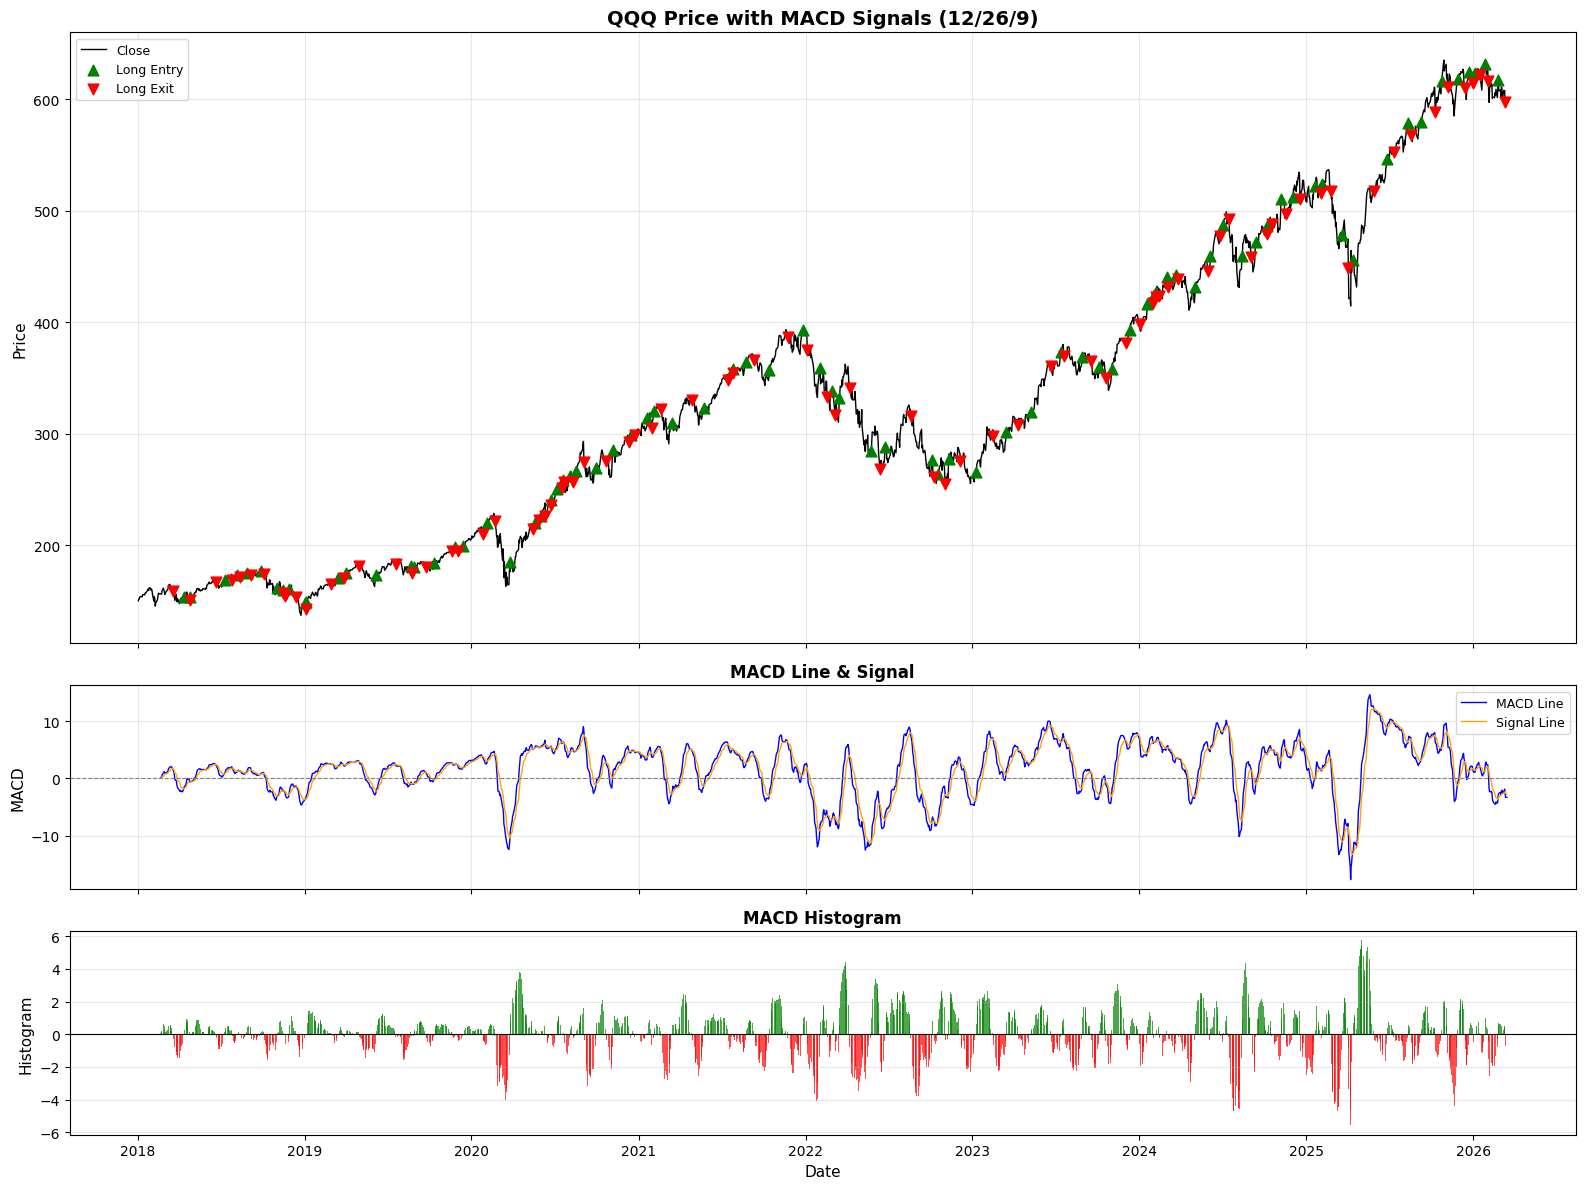

In [5]:
# VISUALIZE MACD SIGNALS (default 12/26/9)

macd_hist_s = pd.Series(macd_hist, index=stock_data.index)
close_s = pd.Series(close_arr, index=stock_data.index)

# Entry: histogram crosses from negative to positive
entry_signals = (macd_hist_s.shift(1) < 0) & (macd_hist_s > 0)
# Exit: histogram crosses from positive to negative
exit_signals = (macd_hist_s.shift(1) > 0) & (macd_hist_s < 0)

print(f"Default MACD(12,26,9) Signals:")
print(f"  Total Entry Signals: {entry_signals.sum()}")
print(f"  Total Exit Signals:  {exit_signals.sum()}")

# 3-panel chart
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

# Price with entry/exit markers
ax1.plot(stock_data.index, close_arr, color='black', linewidth=1, label='Close')
ax1.scatter(stock_data.index[entry_signals.fillna(False).values],
            close_s[entry_signals.fillna(False)],
            marker='^', color='green', s=60, zorder=5, label='Long Entry')
ax1.scatter(stock_data.index[exit_signals.fillna(False).values],
            close_s[exit_signals.fillna(False)],
            marker='v', color='red', s=60, zorder=5, label='Long Exit')
ax1.set_title(f'{TICKER} Price with MACD Signals (12/26/9)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# MACD Line & Signal
ax2.plot(stock_data.index, macd_line, color='blue', linewidth=1, label='MACD Line')
ax2.plot(stock_data.index, signal_line, color='orange', linewidth=1, label='Signal Line')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_title('MACD Line & Signal', fontsize=12, fontweight='bold')
ax2.set_ylabel('MACD', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Histogram
colors = ['green' if v >= 0 else 'red' for v in np.nan_to_num(macd_hist)]
ax3.bar(stock_data.index, np.nan_to_num(macd_hist), color=colors, width=1.5, alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('MACD Histogram', fontsize=12, fontweight='bold')
ax3.set_ylabel('Histogram', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 4: Prepare Price Series & Train/Validation Split

In [6]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKER already exist
def select_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            s = df[('Close', ticker)]
        else:
            cols = [c for c in df.columns if 'Close' in str(c)]
            if not cols:
                raise KeyError("Close not found")
            s = df[cols[0]]
    else:
        s = df['Close']
    return s.astype(float).squeeze()

close = select_close_series(stock_data, TICKER)
close.name = 'price'

# Simple 60/40 split
TRAIN_RATIO = 0.60
split_idx = int(len(close) * TRAIN_RATIO)
train_close = close.iloc[:split_idx].copy()
val_close   = close.iloc[split_idx:].copy()

print(f"Data ready: train={train_close.index[0].date()} → {train_close.index[-1].date()} | "
      f"val={val_close.index[0].date()} → {val_close.index[-1].date()}")
print(f"Train samples: {len(train_close)} | Val samples: {len(val_close)}")

Data ready: train=2018-01-02 → 2022-11-28 | val=2022-11-29 → 2026-03-16
Train samples: 1236 | Val samples: 825


---
## Section 5: MACD Grid Search — EXTENSIVE Parameter Optimization

### Parameter Ranges (Dense Coverage)
- **fast_period:** 3 to 25, step 1 → **23 values**
- **slow_period:** 16 to 52, step 2 → **19 values**
- **signal_period:** 4 to 17, step 1 → **14 values**
- Filter: `fast < slow` (mandatory for MACD)
- Expected: **~4,500+ valid combinations**

### Signal Logic
Uses the `SIGNAL_MODE` configured in Section 1. The same MACD parameters are optimized regardless of mode — only the entry/exit logic changes.

### Cost Model
- Fees: 0.05% (matching FTMO-like conditions)
- Slippage: 0.05%
- Minimum 2 trades/year filter (eliminates dead combos)

In [7]:
# DEFINE EXTENSIVE PARAMETER RANGES

fast_periods = list(range(3, 26, 1))    # 23 values: 3,4,5,...,25
slow_periods = list(range(16, 53, 2))   # 19 values: 16,18,20,...,52
signal_periods = list(range(4, 18, 1))  # 14 values: 4,5,6,...,17

# Generate all valid combinations (fast < slow required for MACD)
macd_combinations = []
for fast, slow, sig in product(fast_periods, slow_periods, signal_periods):
    if fast < slow:
        macd_combinations.append((fast, slow, sig))

print(f"MACD Parameter Ranges:")
print(f"  Fast periods ({len(fast_periods)}):   {fast_periods}")
print(f"  Slow periods ({len(slow_periods)}):   {slow_periods}")
print(f"  Signal periods ({len(signal_periods)}): {signal_periods}")
print(f"\nGenerated {len(macd_combinations)} valid MACD combinations")
print(f"\n📋 First 10 combinations preview:")
for i, (f, s, sg) in enumerate(macd_combinations[:10], 1):
    print(f"  {i:2d}. Fast:{f:2d} | Slow:{s:2d} | Signal:{sg:2d}")
if len(macd_combinations) > 10:
    print(f"   ... and {len(macd_combinations) - 10} more combinations")
print("\nReady to test all combinations on training data!")

MACD Parameter Ranges:
  Fast periods (23):   [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
  Slow periods (19):   [16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52]
  Signal periods (14): [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Generated 5698 valid MACD combinations

📋 First 10 combinations preview:
   1. Fast: 3 | Slow:16 | Signal: 4
   2. Fast: 3 | Slow:16 | Signal: 5
   3. Fast: 3 | Slow:16 | Signal: 6
   4. Fast: 3 | Slow:16 | Signal: 7
   5. Fast: 3 | Slow:16 | Signal: 8
   6. Fast: 3 | Slow:16 | Signal: 9
   7. Fast: 3 | Slow:16 | Signal:10
   8. Fast: 3 | Slow:16 | Signal:11
   9. Fast: 3 | Slow:16 | Signal:12
  10. Fast: 3 | Slow:16 | Signal:13
   ... and 5688 more combinations

Ready to test all combinations on training data!


In [8]:
# INITIALIZE RESULTS COLLECTION

grid_search_results = []

print("MACD Results Collection System Initialized")
print(f"   - Will test {len(macd_combinations)} MACD combinations")
print(f"   - Results will be stored in 'grid_search_results' list")

metrics_to_collect = [
    "fast_period", "slow_period", "signal_period",
    "total_return", "annualized_return", "total_profit",
    "sharpe_ratio", "sortino_ratio",
    "max_drawdown", "volatility", "ulcer_index",
    "win_rate", "total_trades", "avg_trade_duration",
    "expectancy", "profit_factor",
    "payoff_ratio", "avg_win_amount", "avg_loss_amount",
    "trades_per_year"
]

print(f"\nMetrics to collect for each MACD combination:")
for i, metric in enumerate(metrics_to_collect, 1):
    print(f"  {i}. {metric.replace('_', ' ').title()}")
print("\nReady to start the MACD grid search!")

MACD Results Collection System Initialized
   - Will test 5698 MACD combinations
   - Results will be stored in 'grid_search_results' list

Metrics to collect for each MACD combination:
  1. Fast Period
  2. Slow Period
  3. Signal Period
  4. Total Return
  5. Annualized Return
  6. Total Profit
  7. Sharpe Ratio
  8. Sortino Ratio
  9. Max Drawdown
  10. Volatility
  11. Ulcer Index
  12. Win Rate
  13. Total Trades
  14. Avg Trade Duration
  15. Expectancy
  16. Profit Factor
  17. Payoff Ratio
  18. Avg Win Amount
  19. Avg Loss Amount
  20. Trades Per Year

Ready to start the MACD grid search!


In [ ]:
# HELPER: Compute MACD entry/exit signals — supports all 4 signal modes
#
# For 'line_crossover_atr' mode, we generate entries from MACD crossover but
# exits are ATR-based (stop loss / take profit). Since vectorbt's from_signals()
# doesn't natively support price-level stops, we simulate them here by walking
# forward from each entry and marking the exit bar.

def compute_macd_signals(price_series, fast, slow, signal, mode=None,
                         high_series=None, low_series=None):
    """
    Compute MACD-based entry/exit signals.

    Modes:
      'histogram'          — histogram zero-cross (original, low frequency)
      'line_crossover'     — MACD line crosses signal line (medium frequency)
      'macd_v'             — MACD-V (vol-normalized) threshold crossover
      'line_crossover_atr' — MACD line cross entry + ATR stop/target exits (high frequency)

    Returns:
        entries (pd.Series[bool]), exits (pd.Series[bool])
    """
    if mode is None:
        mode = SIGNAL_MODE

    arr = price_series.values.astype(float)
    macd_line, signal_line, hist = talib.MACD(arr, fastperiod=fast, slowperiod=slow, signalperiod=signal)

    macd_s = pd.Series(macd_line, index=price_series.index)
    sig_s = pd.Series(signal_line, index=price_series.index)
    hist_s = pd.Series(hist, index=price_series.index)

    if mode == 'histogram':
        entries_raw = (hist_s.shift(1) < 0) & (hist_s > 0)
        exits_raw = (hist_s.shift(1) > 0) & (hist_s < 0)
        entries = entries_raw.shift(1).fillna(False).astype(bool)
        exits = exits_raw.shift(1).fillna(False).astype(bool)
        return entries, exits

    elif mode == 'line_crossover':
        entries_raw = (macd_s.shift(1) <= sig_s.shift(1)) & (macd_s > sig_s)
        exits_raw = (macd_s.shift(1) >= sig_s.shift(1)) & (macd_s < sig_s)
        entries = entries_raw.shift(1).fillna(False).astype(bool)
        exits = exits_raw.shift(1).fillna(False).astype(bool)
        return entries, exits

    elif mode == 'macd_v':
        # MACD-V = histogram / ATR * 100
        atr = talib.ATR(
            (high_series if high_series is not None else price_series).values.astype(float),
            (low_series if low_series is not None else price_series).values.astype(float),
            arr,
            timeperiod=MACDV_ATR_PERIOD
        )
        atr_s = pd.Series(atr, index=price_series.index).replace(0, np.nan)
        macd_v = (hist_s / atr_s) * 100

        entries_raw = (macd_v.shift(1) <= MACDV_ENTRY_THRESH) & (macd_v > MACDV_ENTRY_THRESH)
        exits_raw = (macd_v.shift(1) >= MACDV_EXIT_THRESH) & (macd_v < MACDV_EXIT_THRESH)
        entries = entries_raw.shift(1).fillna(False).astype(bool)
        exits = exits_raw.shift(1).fillna(False).astype(bool)
        return entries, exits

    elif mode == 'line_crossover_atr':
        # Entry: MACD line crosses above signal line
        entries_raw = (macd_s.shift(1) <= sig_s.shift(1)) & (macd_s > sig_s)
        entry_signals = entries_raw.shift(1).fillna(False).astype(bool)

        # ATR for stop/target levels
        atr = talib.ATR(
            (high_series if high_series is not None else price_series).values.astype(float),
            (low_series if low_series is not None else price_series).values.astype(float),
            arr,
            timeperiod=ATR_PERIOD
        )

        # Walk forward to compute ATR-based exits
        prices = price_series.values
        entries_out = np.zeros(len(prices), dtype=bool)
        exits_out = np.zeros(len(prices), dtype=bool)
        in_trade = False

        for i in range(len(prices)):
            if not in_trade and entry_signals.iloc[i]:
                # Enter trade
                in_trade = True
                entries_out[i] = True
                entry_price = prices[i]
                atr_val = atr[i] if not np.isnan(atr[i]) else atr[max(0, i-1)]
                if np.isnan(atr_val):
                    atr_val = prices[i] * 0.02  # fallback: 2% of price
                sl_level = entry_price - ATR_SL_MULT * atr_val
                tp_level = entry_price + ATR_TP_MULT * atr_val
            elif in_trade:
                # Check stop loss or take profit
                if prices[i] <= sl_level or prices[i] >= tp_level:
                    exits_out[i] = True
                    in_trade = False
                # Also check if opposite MACD crossover fires (secondary exit)
                elif i > 0 and not np.isnan(macd_line[i]) and not np.isnan(signal_line[i]):
                    if macd_line[i] < signal_line[i] and macd_line[i-1] >= signal_line[i-1]:
                        exits_out[i] = True
                        in_trade = False

        entries = pd.Series(entries_out, index=price_series.index)
        exits = pd.Series(exits_out, index=price_series.index)
        return entries, exits

    else:
        raise ValueError(f"Unknown SIGNAL_MODE: {mode}")

print(f"Signal computation function defined (mode: {SIGNAL_MODE})")

# Quick frequency check on training data
_test_entries, _test_exits = compute_macd_signals(train_close, 12, 26, 9)
_test_years = (train_close.index[-1] - train_close.index[0]).days / 365.25
print(f"  Default MACD(12,26,9) on train data: {_test_entries.sum()} entries = {_test_entries.sum()/_test_years:.1f}/year")

In [10]:
# VISUALIZE SIGNALS FOR ONE EXAMPLE BEFORE GRID SEARCH

example_fast, example_slow, example_sig = 12, 26, 9
entries_ex, exits_ex = compute_macd_signals(train_close, example_fast, example_slow, example_sig)

# Build signal verification table
arr_ex = train_close.values.astype(float)
ml, sl, hl = talib.MACD(arr_ex, fastperiod=example_fast, slowperiod=example_slow, signalperiod=example_sig)

signals_df = pd.DataFrame({
    'Close': train_close.values,
    'MACD': ml,
    'Signal': sl,
    'Hist': hl,
    'Buy': entries_ex.values,
    'Sell': exits_ex.values
}, index=train_close.index)
signals_df.index.name = 'Date'

# Track position state
pos = 0
pos_list = []
for buy, sell in zip(signals_df['Buy'], signals_df['Sell']):
    if buy: pos = 1
    elif sell: pos = 0
    pos_list.append(pos)
signals_df['Position'] = pos_list

buy_count = signals_df['Buy'].sum()
sell_count = signals_df['Sell'].sum()
print(f"Example MACD({example_fast},{example_slow},{example_sig}) on training data:")
print(f"  Entry signals: {buy_count}")
print(f"  Exit signals:  {sell_count}")
print(f"\nFirst rows with signals:")
signal_rows = signals_df[(signals_df['Buy']) | (signals_df['Sell'])]
print(signal_rows.head(20).to_string())

Example MACD(12,26,9) on training data:
  Entry signals: 47
  Exit signals:  47

First rows with signals:
                 Close      MACD    Signal      Hist    Buy   Sell  Position
Date                                                                        
2018-03-20  159.362732  1.320231  1.617876 -0.297646  False   True         0
2018-04-13  153.393250 -1.410143 -1.698599  0.288456   True  False         1
2018-04-26  153.982544 -0.586800 -0.621722  0.034922  False   True         0
2018-04-27  154.077576 -0.501930 -0.597764  0.095834   True  False         1
2018-06-22  167.010361  2.148754  2.352776 -0.204023  False   True         0
2018-07-11  168.058197  1.040627  0.848720  0.191908   True  False         1
2018-07-30  166.810318  1.262461  1.673072 -0.410611  False   True         0
2018-08-08  173.392792  1.364175  1.254256  0.109919   True  False         1
2018-08-14  172.849823  1.266974  1.288636 -0.021662  False   True         0
2018-08-28  175.860016  1.257513  1.003363  0.2

In [11]:
# MACD GRID SEARCH ON TRAINING DATA — VECTORIZED & BATCHED

print("INITIATING VECTORIZED MACD GRID SEARCH OPTIMIZATION")
print("=" * 70)
print(f"Testing Strategy: Standard MACD Histogram Crossover")
print(f"Training Period: {train_close.index[0].date()} → {train_close.index[-1].date()}")
print(f"Initial Capital: $100,000")
print(f"Transaction Costs: 0.05% fees + 0.05% slippage per trade")
print(f"Optimization Metric: Sharpe Ratio (risk-adjusted returns)")
print("=" * 70)

# Configuration
BATCH_SIZE = 500  # Good balance: TA-Lib per-combo but vectorized backtest
total_combinations = len(macd_combinations)

print(f"Total combinations to test: {total_combinations}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Using vectorized backtesting for maximum speed\n")

grid_search_results = []
successful_tests = 0
failed_tests = 0

print("Starting batched grid search...\n")

for batch_start in range(0, total_combinations, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, total_combinations)
    batch_combos = macd_combinations[batch_start:batch_end]
    batch_size = len(batch_combos)

    batch_num = batch_start // BATCH_SIZE + 1
    total_batches = (total_combinations + BATCH_SIZE - 1) // BATCH_SIZE

    print(f"Processing batch {batch_num}/{total_batches}")
    print(f"  Combinations {batch_start+1} to {batch_end}...")

    # Build signal matrices for this batch
    batch_entries = []
    batch_exits = []
    valid_combos_in_batch = []

    for fast, slow, sig in batch_combos:
        try:
            entries, exits = compute_macd_signals(train_close, fast, slow, sig)
            batch_entries.append(entries)
            batch_exits.append(exits)
            valid_combos_in_batch.append((fast, slow, sig))
        except Exception as e:
            batch_entries.append(pd.Series(False, index=train_close.index, dtype=bool))
            batch_exits.append(pd.Series(False, index=train_close.index, dtype=bool))
            valid_combos_in_batch.append((fast, slow, sig))
            failed_tests += 1

    # Convert to DataFrame for vectorized backtesting
    entries_df = pd.DataFrame(batch_entries).T
    entries_df.index = train_close.index
    exits_df = pd.DataFrame(batch_exits).T
    exits_df.index = train_close.index

    # Vectorized backtest for entire batch at once
    print(f"  Running vectorized backtest on {batch_size} combinations...")
    try:
        portfolios = vbt.Portfolio.from_signals(
            close=train_close,
            entries=entries_df,
            exits=exits_df,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq='D'
        )

        # Extract batch metrics
        total_returns = portfolios.total_return()
        annualized_returns = portfolios.annualized_return(freq='D')
        max_drawdowns = portfolios.max_drawdown()
        volatilities = portfolios.annualized_volatility(freq='D')
        sharpe_ratios = portfolios.sharpe_ratio(freq='D')
        sortino_ratios = portfolios.sortino_ratio(freq='D')

        # Process each result
        for idx, (fast, slow, sig) in enumerate(valid_combos_in_batch):
            try:
                total_return = float(total_returns.iloc[idx] if hasattr(total_returns, 'iloc') else total_returns)
                annualized_return = float(annualized_returns.iloc[idx] if hasattr(annualized_returns, 'iloc') else annualized_returns)
                max_drawdown = float(max_drawdowns.iloc[idx] if hasattr(max_drawdowns, 'iloc') else max_drawdowns)
                volatility = float(volatilities.iloc[idx] if hasattr(volatilities, 'iloc') else volatilities)
                sharpe_ratio = float(sharpe_ratios.iloc[idx] if hasattr(sharpe_ratios, 'iloc') else sharpe_ratios)
                sortino_ratio = float(sortino_ratios.iloc[idx] if hasattr(sortino_ratios, 'iloc') else sortino_ratios)

                # Get trade-level metrics
                trades = portfolios[idx].trades if batch_size > 1 else portfolios.trades
                total_trades = len(trades)

                # Trades per year filter
                years = max((train_close.index[-1] - train_close.index[0]).days / 365.25, 1e-9)
                trades_per_year = total_trades / years

                if trades_per_year < 2:
                    continue

                # Trade statistics
                win_rate_pct = np.nan
                profit_factor = np.nan
                expectancy = 0.0
                avg_win_amount = 0.0
                avg_loss_amount = 0.0
                payoff_ratio = np.nan
                avg_duration = np.nan

                if total_trades > 0:
                    tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
                    if tr.size > 0:
                        pos = tr[tr > 0]
                        neg = tr[tr < 0]
                        win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                        gains = pos.sum() if len(pos) else 0.0
                        losses = abs(neg.sum()) if len(neg) else 0.0
                        profit_factor = gains / losses if losses > 0 else np.inf
                        expectancy = float(tr.mean())
                        avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                        avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0
                        payoff_ratio = (avg_win_amount / avg_loss_amount) if avg_loss_amount not in (0.0, np.nan) else np.inf

                    # Average trade duration
                    try:
                        durations = trades.duration
                        if hasattr(durations, 'mean'):
                            d_mean = durations.mean()
                            avg_duration = float(d_mean.total_seconds() / 86400) if hasattr(d_mean, 'total_seconds') else float(d_mean)
                    except:
                        pass

                # Ulcer Index
                try:
                    returns_series = portfolios.returns().iloc[:, idx] if batch_size > 1 else portfolios.returns()
                    cum = (1 + returns_series).cumprod()
                    peak = cum.cummax()
                    dd = (cum - peak) / peak
                    ulcer_index = float(np.sqrt((dd.pow(2)).mean()))
                except:
                    ulcer_index = np.nan

                grid_search_results.append({
                    "fast_period": fast,
                    "slow_period": slow,
                    "signal_period": sig,
                    "total_return": total_return,
                    "annualized_return": annualized_return,
                    "max_drawdown": max_drawdown,
                    "volatility": volatility,
                    "sharpe_ratio": sharpe_ratio,
                    "sortino_ratio": sortino_ratio,
                    "ulcer_index": ulcer_index,
                    "total_trades": total_trades,
                    "win_rate": win_rate_pct,
                    "profit_factor": profit_factor,
                    "expectancy": expectancy,
                    "avg_win_amount": avg_win_amount,
                    "avg_loss_amount": avg_loss_amount,
                    "payoff_ratio": payoff_ratio,
                    "avg_trade_duration": avg_duration,
                    "trades_per_year": trades_per_year
                })
                successful_tests += 1

            except Exception as e:
                failed_tests += 1

    except Exception as e:
        print(f"  ⚠️ Batch failed: {str(e)[:100]}")
        failed_tests += batch_size

    # Progress update
    progress_pct = (batch_end / total_combinations) * 100
    print(f"  ✓ Batch complete: {successful_tests} successful, {failed_tests} failed")
    print(f"  Overall progress: {batch_end}/{total_combinations} ({progress_pct:.1f}%)\n")

# SUMMARY
print("=" * 70)
print("VECTORIZED GRID SEARCH COMPLETED!")
print("=" * 70)
print(f"Total combinations attempted: {total_combinations}")
print(f"Successfully completed: {successful_tests}")
print(f"Failed: {failed_tests}")
print(f"Success rate: {(successful_tests/total_combinations)*100:.1f}%")
print(f"\n✓ Results stored in 'grid_search_results' ({len(grid_search_results)} entries)")

if successful_tests > 0:
    results_df_preview = pd.DataFrame(grid_search_results)

    print("\n" + "=" * 70)
    print("🏆 TOP 5 COMBINATIONS (by In-Sample Sharpe Ratio)")
    print("=" * 70)

    top_5 = results_df_preview.nlargest(5, 'sharpe_ratio')
    for rank, (idx, row) in enumerate(top_5.iterrows(), 1):
        print(f"\n#{rank} - MACD({int(row['fast_period'])}, {int(row['slow_period'])}, {int(row['signal_period'])})")
        print(f"   Sharpe Ratio:      {row['sharpe_ratio']:.3f}")
        print(f"   Total Return:      {row['total_return']:.2%}")
        print(f"   Annualized Return: {row['annualized_return']:.2%}")
        print(f"   Max Drawdown:      {row['max_drawdown']:.2%}")
        print(f"   Win Rate:          {row['win_rate']:.1f}%")
        print(f"   Profit Factor:     {row['profit_factor']:.2f}")
        print(f"   Total Trades:      {int(row['total_trades'])} ({row['trades_per_year']:.1f}/year)")

    print("\n" + "=" * 70)

INITIATING VECTORIZED MACD GRID SEARCH OPTIMIZATION
Testing Strategy: Standard MACD Histogram Crossover
Training Period: 2018-01-02 → 2022-11-28
Initial Capital: $100,000
Transaction Costs: 0.05% fees + 0.05% slippage per trade
Optimization Metric: Sharpe Ratio (risk-adjusted returns)
Total combinations to test: 5698
Batch size: 500
Using vectorized backtesting for maximum speed

Starting batched grid search...

Processing batch 1/12
  Combinations 1 to 500...
  Running vectorized backtest on 500 combinations...
  ✓ Batch complete: 500 successful, 0 failed
  Overall progress: 500/5698 (8.8%)

Processing batch 2/12
  Combinations 501 to 1000...
  Running vectorized backtest on 500 combinations...
  ✓ Batch complete: 1000 successful, 0 failed
  Overall progress: 1000/5698 (17.6%)

Processing batch 3/12
  Combinations 1001 to 1500...
  Running vectorized backtest on 500 combinations...
  ✓ Batch complete: 1500 successful, 0 failed
  Overall progress: 1500/5698 (26.3%)

Processing batch 4/

---
## Section 6: Results Display & Analysis

In [12]:
# GRID SEARCH RESULTS ANALYSIS

results_df = pd.DataFrame(grid_search_results)

print("Grid Search Results Analysis")
print("=" * 50)
print(f"Total combinations tested: {len(results_df)}")
print(f"Results shape: {results_df.shape}")

print("\nComprehensive Performance Statistics:")
print("-" * 50)
print("Return Metrics:")
print(f"   Best Total Return: {results_df['total_return'].max():.2%}")
print(f"   Average Total Return: {results_df['total_return'].mean():.2%}")
print(f"   Best Annualized Return: {results_df['annualized_return'].max():.2%}")
print("Risk-Adjusted Return Metrics:")
print(f"   Best Sharpe Ratio: {results_df['sharpe_ratio'].max():.3f}")
print(f"   Median Sharpe Ratio: {results_df['sharpe_ratio'].median():.3f}")
print(f"   75th Percentile Sharpe: {results_df['sharpe_ratio'].quantile(0.75):.3f}")
print(f"   Best Sortino Ratio: {results_df['sortino_ratio'].max():.3f}")
print("Risk Metrics:")
print(f"   Average Max Drawdown: {results_df['max_drawdown'].mean():.2%}")
print(f"   Best (smallest) Max DD: {results_df['max_drawdown'].max():.2%}")
print(f"   Average Volatility: {results_df['volatility'].mean():.2%}")
print("Trade Performance:")
print(f"   Best Win Rate: {results_df['win_rate'].max():.1f}%")
print(f"   Average Win Rate: {results_df['win_rate'].mean():.1f}%")
print(f"   Best Profit Factor: {results_df['profit_factor'].replace([np.inf], np.nan).max():.2f}")
print(f"   Avg Trades/Year: {results_df['trades_per_year'].mean():.1f}")

# Sharpe distribution
print("\nSharpe Ratio Distribution:")
for threshold in [0.5, 1.0, 1.5, 2.0]:
    count = (results_df['sharpe_ratio'] >= threshold).sum()
    pct = count / len(results_df) * 100
    print(f"   Sharpe >= {threshold:.1f}: {count:4d} combos ({pct:.1f}%)")

# Display top 50 sorted by Sharpe
print("\n" + "=" * 90)
print("TOP 50 PARAMETER COMBINATIONS (sorted by IS Sharpe Ratio)")
print("=" * 90)

display_cols = ['fast_period', 'slow_period', 'signal_period',
                'sharpe_ratio', 'total_return', 'annualized_return', 'max_drawdown',
                'win_rate', 'profit_factor', 'total_trades', 'trades_per_year']
top_50 = results_df.nlargest(50, 'sharpe_ratio')[display_cols].copy()
top_50['total_return'] = top_50['total_return'].apply(lambda x: f"{x:.2%}")
top_50['annualized_return'] = top_50['annualized_return'].apply(lambda x: f"{x:.2%}")
top_50['max_drawdown'] = top_50['max_drawdown'].apply(lambda x: f"{x:.2%}")
top_50['sharpe_ratio'] = top_50['sharpe_ratio'].apply(lambda x: f"{x:.3f}")
top_50['win_rate'] = top_50['win_rate'].apply(lambda x: f"{x:.1f}%")
top_50['profit_factor'] = top_50['profit_factor'].apply(lambda x: f"{x:.2f}")
print(top_50.to_string(index=False))

Grid Search Results Analysis
Total combinations tested: 5698
Results shape: (5698, 19)

Comprehensive Performance Statistics:
--------------------------------------------------
Return Metrics:
   Best Total Return: 51.38%
   Average Total Return: 25.02%
   Best Annualized Return: 13.03%
Risk-Adjusted Return Metrics:
   Best Sharpe Ratio: 0.802
   Median Sharpe Ratio: 0.470
   75th Percentile Sharpe: 0.540
   Best Sortino Ratio: 1.125
Risk Metrics:
   Average Max Drawdown: -28.15%
   Best (smallest) Max DD: -18.84%
   Average Volatility: 18.31%
Trade Performance:
   Best Win Rate: 56.6%
   Average Win Rate: 44.4%
   Best Profit Factor: 2.16
   Avg Trades/Year: 10.1

Sharpe Ratio Distribution:
   Sharpe >= 0.5: 2213 combos (38.8%)
   Sharpe >= 1.0:    0 combos (0.0%)
   Sharpe >= 1.5:    0 combos (0.0%)
   Sharpe >= 2.0:    0 combos (0.0%)

TOP 50 PARAMETER COMBINATIONS (sorted by IS Sharpe Ratio)
 fast_period  slow_period  signal_period sharpe_ratio total_return annualized_return max_dr

---
## Section 7: Out-of-Sample Validation — IS vs OOS Comparison

In [13]:
# OUT-OF-SAMPLE VALIDATION FOR TOP COMBINATIONS

results_df_raw = pd.DataFrame(grid_search_results)

# Take top 50 IS combinations to validate OOS
top_n = min(50, len(results_df_raw))
top_is = results_df_raw.nlargest(top_n, 'sharpe_ratio').copy()

oos_results = []

print(f"Validating top {top_n} IS combinations on OOS data...")
print(f"OOS Period: {val_close.index[0].date()} → {val_close.index[-1].date()}\n")

for _, row in top_is.iterrows():
    fast = int(row['fast_period'])
    slow = int(row['slow_period'])
    sig = int(row['signal_period'])

    try:
        entries_oos, exits_oos = compute_macd_signals(val_close, fast, slow, sig)

        pf_oos = vbt.Portfolio.from_signals(
            close=val_close,
            entries=entries_oos,
            exits=exits_oos,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq='D'
        )

        oos_sharpe = float(pf_oos.sharpe_ratio(freq='D'))
        oos_return = float(pf_oos.total_return())
        oos_maxdd = float(pf_oos.max_drawdown())
        oos_trades = len(pf_oos.trades)

        oos_win_rate = np.nan
        oos_profit_factor = np.nan
        if oos_trades > 0:
            tr = pf_oos.trades.returns.values
            pos = tr[tr > 0]
            neg = tr[tr < 0]
            oos_win_rate = (len(pos) / len(tr)) * 100.0
            gains = pos.sum() if len(pos) else 0.0
            losses = abs(neg.sum()) if len(neg) else 0.0
            oos_profit_factor = gains / losses if losses > 0 else np.inf

        oos_results.append({
            'fast_period': fast, 'slow_period': slow, 'signal_period': sig,
            'is_sharpe': float(row['sharpe_ratio']),
            'is_return': float(row['total_return']),
            'is_maxdd': float(row['max_drawdown']),
            'is_win_rate': float(row['win_rate']),
            'is_trades': int(row['total_trades']),
            'oos_sharpe': oos_sharpe,
            'oos_return': oos_return,
            'oos_maxdd': oos_maxdd,
            'oos_win_rate': oos_win_rate,
            'oos_profit_factor': oos_profit_factor,
            'oos_trades': oos_trades
        })
    except Exception as e:
        pass

oos_df = pd.DataFrame(oos_results).sort_values('is_sharpe', ascending=False)

print("\n" + "=" * 100)
print("IS vs OOS COMPARISON TABLE")
print("=" * 100)
print("Interpretation: OOS Sharpe within 30% of IS Sharpe = ROBUST")
print("               FTMO Max DD: Must stay under 10% daily\n")

# Sharpe decay
display_oos = oos_df.copy()
display_oos['sharpe_decay'] = ((display_oos['oos_sharpe'] - display_oos['is_sharpe']) /
                                display_oos['is_sharpe'].abs() * 100)
display_oos['robust'] = display_oos['sharpe_decay'].abs() < 30

for col in ['is_sharpe', 'oos_sharpe']:
    display_oos[col] = display_oos[col].apply(lambda x: f"{x:.3f}")
for col in ['is_return', 'oos_return', 'is_maxdd', 'oos_maxdd']:
    display_oos[col] = display_oos[col].apply(lambda x: f"{x:.2%}")
display_oos['sharpe_decay'] = display_oos['sharpe_decay'].apply(lambda x: f"{x:.1f}%")
display_oos['robust'] = display_oos['robust'].apply(lambda x: '✅' if x else '❌')

print(display_oos[['fast_period', 'slow_period', 'signal_period',
                    'is_sharpe', 'is_return', 'is_maxdd',
                    'oos_sharpe', 'oos_return', 'oos_maxdd', 'oos_trades',
                    'sharpe_decay', 'robust']].head(30).to_string(index=False))

robust_count = sum(1 for r in oos_results
                   if abs((r['oos_sharpe'] - r['is_sharpe']) / max(abs(r['is_sharpe']), 1e-9)) < 0.3)
print(f"\n✅ Robust combinations (OOS within 30% of IS): {robust_count}/{len(oos_results)}")

Validating top 50 IS combinations on OOS data...
OOS Period: 2022-11-29 → 2026-03-16


IS vs OOS COMPARISON TABLE
Interpretation: OOS Sharpe within 30% of IS Sharpe = ROBUST
               FTMO Max DD: Must stay under 10% daily

 fast_period  slow_period  signal_period is_sharpe is_return is_maxdd oos_sharpe oos_return oos_maxdd  oos_trades sharpe_decay robust
          25           50             14     0.802    51.38%  -19.43%      0.976     29.68%   -11.28%          21        21.7%      ✅
          25           52             14     0.787    49.84%  -20.60%      0.971     29.42%   -11.05%          20        23.4%      ✅
          25           52              6     0.782    50.88%  -20.58%      0.738     21.48%   -12.96%          26        -5.6%      ✅
          24           52             17     0.770    48.70%  -21.31%      1.068     32.59%   -11.53%          19        38.7%      ❌
          25           52             16     0.766    48.29%  -21.31%      0.875     26.04%   -11.71%

---
## Section 8: Sensitivity Analysis (CRITICAL — Rick's Framework)

For each of the 3 parameters, vary ±5 steps while holding the others at the **base** (best IS Sharpe) values.  
Compute Sharpe delta % to identify fragile vs. robust parameters.

**Color Code:**
- 🟢 Dark Green: Δ > +10%  
- 🟢 Light Green: 0% < Δ < +10%  
- 🟠 Orange: -10% < Δ < 0%  
- 🔴 Red: Δ < -10%

---

📊 BASE PARAMETERS (Best IS Sharpe):
   MACD(25, 50, 14)
   IS Sharpe:  0.802
   IS Return:  51.38%
   IS MaxDD:   -19.43%

📐 Variation Ranges:
   Fast:   [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   Slow:   [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]
   Signal: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

🔄 Testing 31 parameter variations...
   Base IS Sharpe:  0.802
   Base OOS Sharpe: 0.976


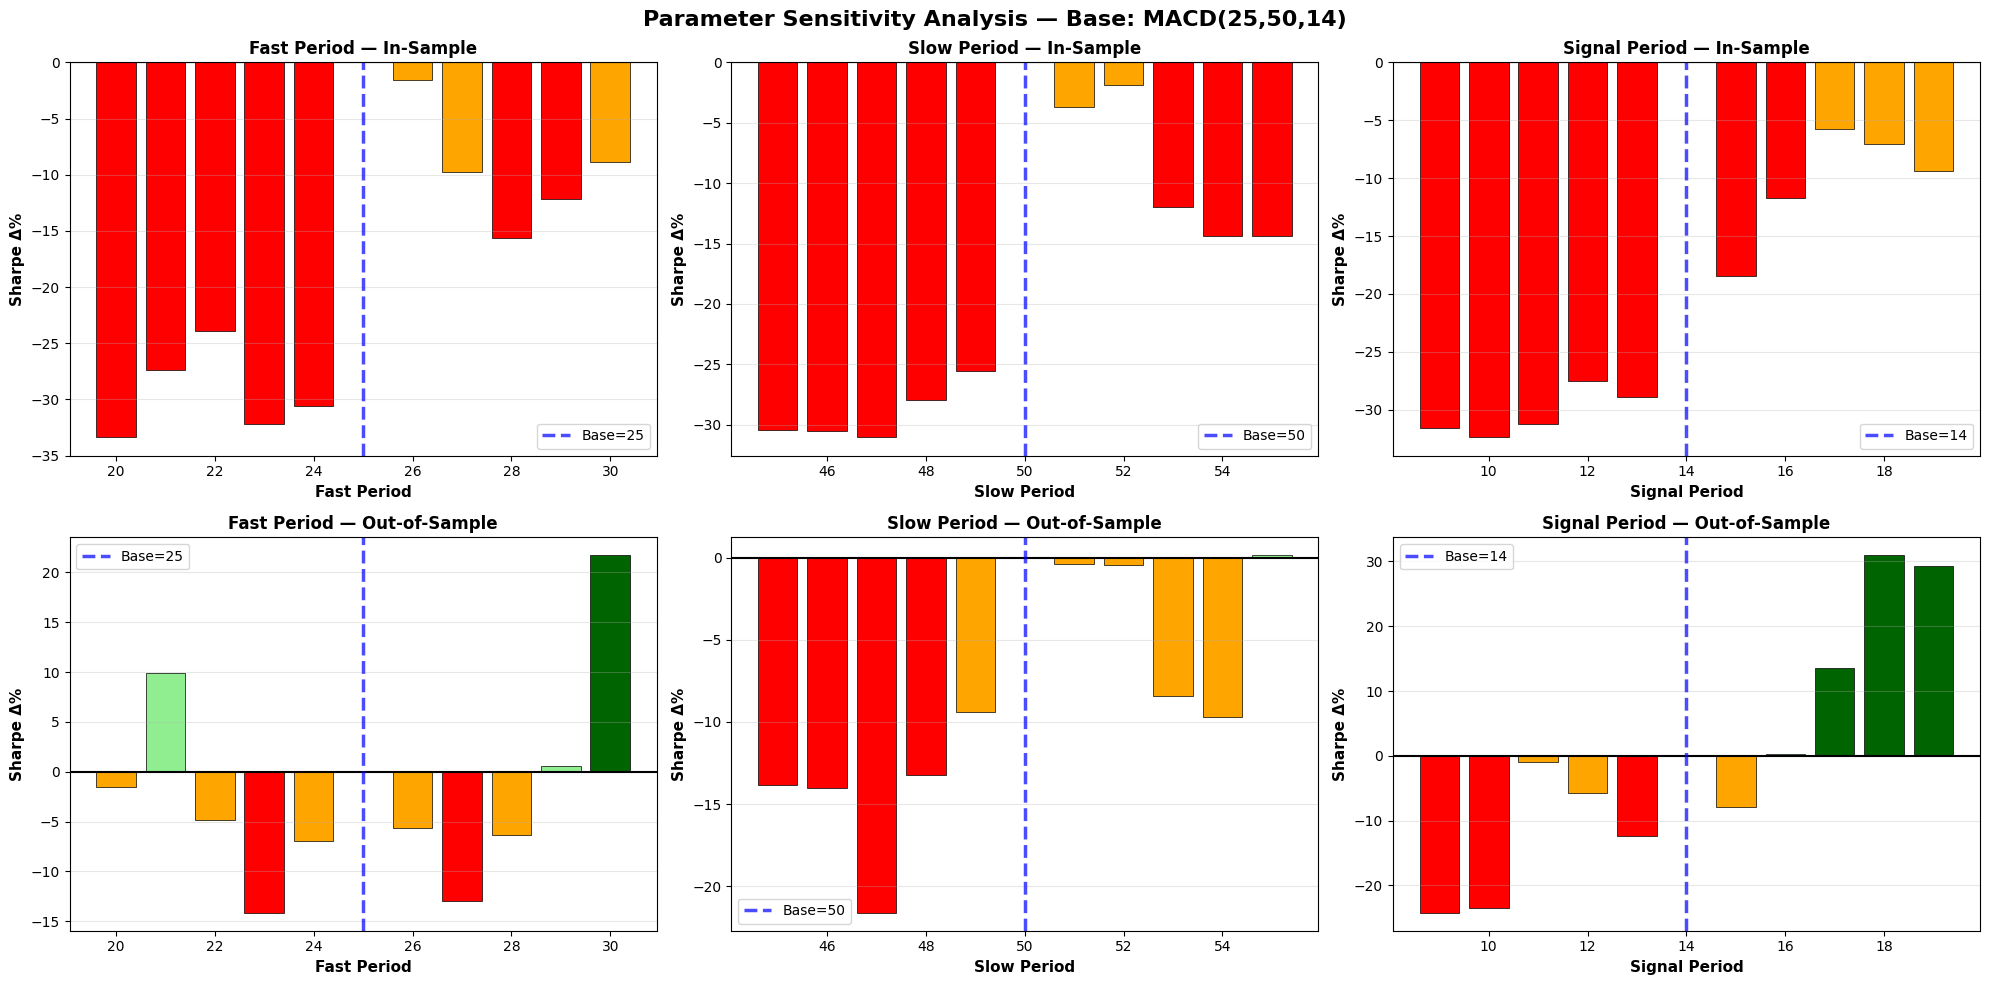


📋 SENSITIVITY SUMMARY
Parameter      IS Range IS Max Δ%     OOS Range OOS Max Δ% Sensitivity
     Fast 0.535 — 0.802    -33.3% 0.838 — 1.188     -14.2%       ✅ LOW
     Slow 0.553 — 0.802    -31.0% 0.765 — 0.977     -21.6%       ✅ LOW
   Signal 0.542 — 0.802    -32.4% 0.739 — 1.278     -24.2%       ✅ LOW

✅ Analysis Complete! Green = Robust, Red = Fragile


In [14]:
# SENSITIVITY ANALYSIS — RICK'S FRAMEWORK

results_df = pd.DataFrame(grid_search_results)
FREQ = '1D'

# Identify base parameters (best IS Sharpe)
best_row = results_df.loc[results_df['sharpe_ratio'].idxmax()]
fast_base = int(best_row['fast_period'])
slow_base = int(best_row['slow_period'])
signal_base = int(best_row['signal_period'])

# Get base IS sharpe
base_is_sharpe = float(best_row['sharpe_ratio'])

print(f"📊 BASE PARAMETERS (Best IS Sharpe):")
print(f"   MACD({fast_base}, {slow_base}, {signal_base})")
print(f"   IS Sharpe:  {base_is_sharpe:.3f}")
print(f"   IS Return:  {best_row['total_return']:.2%}")
print(f"   IS MaxDD:   {best_row['max_drawdown']:.2%}")

# Generate variation ranges (±5 around base)
fast_range = list(range(max(2, fast_base - 5), fast_base + 6))
slow_range = list(range(max(fast_base + 2, slow_base - 5), slow_base + 6))
signal_range = list(range(max(2, signal_base - 5), signal_base + 6))

print(f"\n📐 Variation Ranges:")
print(f"   Fast:   {fast_range}")
print(f"   Slow:   {slow_range}")
print(f"   Signal: {signal_range}")

# Build all sensitivity combos
all_combos = set()
for f in fast_range:
    if f < slow_base:
        all_combos.add((f, slow_base, signal_base))
for s in slow_range:
    if fast_base < s:
        all_combos.add((fast_base, s, signal_base))
for sg in signal_range:
    all_combos.add((fast_base, slow_base, sg))

all_combos = sorted(list(all_combos))

# Evaluate each on both IS and OOS
def eval_combo_both(fast, slow, sig):
    entries_is, exits_is = compute_macd_signals(train_close, fast, slow, sig)
    pf_is = vbt.Portfolio.from_signals(
        close=train_close, entries=entries_is, exits=exits_is,
        init_cash=100_000, fees=0.0005, slippage=0.0005, freq=FREQ
    )
    entries_oos, exits_oos = compute_macd_signals(val_close, fast, slow, sig)
    pf_oos = vbt.Portfolio.from_signals(
        close=val_close, entries=entries_oos, exits=exits_oos,
        init_cash=100_000, fees=0.0005, slippage=0.0005, freq=FREQ
    )
    return {
        'fast': fast, 'slow': slow, 'signal': sig,
        'is_sharpe': float(pf_is.sharpe_ratio(freq='D')),
        'is_return': float(pf_is.total_return()),
        'is_maxdd': float(pf_is.max_drawdown()),
        'oos_sharpe': float(pf_oos.sharpe_ratio(freq='D')),
        'oos_return': float(pf_oos.total_return()),
        'oos_maxdd': float(pf_oos.max_drawdown()),
        'oos_trades': len(pf_oos.trades)
    }

print(f"\n🔄 Testing {len(all_combos)} parameter variations...")

rows = []
for combo in all_combos:
    try:
        rows.append(eval_combo_both(*combo))
    except Exception:
        pass

if not rows:
    print("❌ No sensitivity results computed.")
else:
    sens_df = pd.DataFrame(rows)

    # Get OOS sharpe for base
    base_oos_row = sens_df[(sens_df['fast'] == fast_base) & (sens_df['slow'] == slow_base) &
                           (sens_df['signal'] == signal_base)]
    base_oos_sharpe = float(base_oos_row['oos_sharpe'].iloc[0]) if len(base_oos_row) > 0 else np.nan

    print(f"   Base IS Sharpe:  {base_is_sharpe:.3f}")
    print(f"   Base OOS Sharpe: {base_oos_sharpe:.3f}")

    # Split by parameter variation type
    fast_variations = sens_df[(sens_df['slow'] == slow_base) & (sens_df['signal'] == signal_base)].copy().sort_values('fast')
    slow_variations = sens_df[(sens_df['fast'] == fast_base) & (sens_df['signal'] == signal_base)].copy().sort_values('slow')
    signal_variations = sens_df[(sens_df['fast'] == fast_base) & (sens_df['slow'] == slow_base)].copy().sort_values('signal')

    # Calculate degradations
    fast_variations['is_sharpe_delta'] = ((fast_variations['is_sharpe'] - base_is_sharpe) / abs(base_is_sharpe) * 100)
    slow_variations['is_sharpe_delta'] = ((slow_variations['is_sharpe'] - base_is_sharpe) / abs(base_is_sharpe) * 100)
    signal_variations['is_sharpe_delta'] = ((signal_variations['is_sharpe'] - base_is_sharpe) / abs(base_is_sharpe) * 100)

    if not np.isnan(base_oos_sharpe) and abs(base_oos_sharpe) > 1e-6:
        fast_variations['oos_sharpe_delta'] = ((fast_variations['oos_sharpe'] - base_oos_sharpe) / abs(base_oos_sharpe) * 100)
        slow_variations['oos_sharpe_delta'] = ((slow_variations['oos_sharpe'] - base_oos_sharpe) / abs(base_oos_sharpe) * 100)
        signal_variations['oos_sharpe_delta'] = ((signal_variations['oos_sharpe'] - base_oos_sharpe) / abs(base_oos_sharpe) * 100)

    # ============================================================
    # CREATE BAR CHARTS — 6-PANEL LAYOUT (3 params × IS/OOS)
    # ============================================================
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f'Parameter Sensitivity Analysis — Base: MACD({fast_base},{slow_base},{signal_base})',
                 fontsize=16, fontweight='bold')

    # IN-SAMPLE BAR CHARTS
    # Fast IS
    colors1_is = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                  for x in fast_variations['is_sharpe_delta']]
    axes[0, 0].bar(fast_variations['fast'], fast_variations['is_sharpe_delta'], color=colors1_is, edgecolor='black', linewidth=0.5)
    axes[0, 0].axhline(0, color='black', linewidth=1.5)
    axes[0, 0].axvline(fast_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={fast_base}')
    axes[0, 0].set_xlabel('Fast Period', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Fast Period — In-Sample', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].legend(fontsize=10)

    # Slow IS
    colors2_is = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                  for x in slow_variations['is_sharpe_delta']]
    axes[0, 1].bar(slow_variations['slow'], slow_variations['is_sharpe_delta'], color=colors2_is, edgecolor='black', linewidth=0.5)
    axes[0, 1].axhline(0, color='black', linewidth=1.5)
    axes[0, 1].axvline(slow_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={slow_base}')
    axes[0, 1].set_xlabel('Slow Period', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Slow Period — In-Sample', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].legend(fontsize=10)

    # Signal IS
    colors3_is = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                  for x in signal_variations['is_sharpe_delta']]
    axes[0, 2].bar(signal_variations['signal'], signal_variations['is_sharpe_delta'], color=colors3_is, edgecolor='black', linewidth=0.5)
    axes[0, 2].axhline(0, color='black', linewidth=1.5)
    axes[0, 2].axvline(signal_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={signal_base}')
    axes[0, 2].set_xlabel('Signal Period', fontsize=11, fontweight='bold')
    axes[0, 2].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
    axes[0, 2].set_title('Signal Period — In-Sample', fontsize=12, fontweight='bold')
    axes[0, 2].grid(axis='y', alpha=0.3)
    axes[0, 2].legend(fontsize=10)

    # OUT-OF-SAMPLE BAR CHARTS
    if not np.isnan(base_oos_sharpe) and abs(base_oos_sharpe) > 1e-6:
        # Fast OOS
        colors1_oos = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                      for x in fast_variations['oos_sharpe_delta']]
        axes[1, 0].bar(fast_variations['fast'], fast_variations['oos_sharpe_delta'], color=colors1_oos, edgecolor='black', linewidth=0.5)
        axes[1, 0].axhline(0, color='black', linewidth=1.5)
        axes[1, 0].axvline(fast_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={fast_base}')
        axes[1, 0].set_xlabel('Fast Period', fontsize=11, fontweight='bold')
        axes[1, 0].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Fast Period — Out-of-Sample', fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].legend(fontsize=10)

        # Slow OOS
        colors2_oos = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                      for x in slow_variations['oos_sharpe_delta']]
        axes[1, 1].bar(slow_variations['slow'], slow_variations['oos_sharpe_delta'], color=colors2_oos, edgecolor='black', linewidth=0.5)
        axes[1, 1].axhline(0, color='black', linewidth=1.5)
        axes[1, 1].axvline(slow_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={slow_base}')
        axes[1, 1].set_xlabel('Slow Period', fontsize=11, fontweight='bold')
        axes[1, 1].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
        axes[1, 1].set_title('Slow Period — Out-of-Sample', fontsize=12, fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)
        axes[1, 1].legend(fontsize=10)

        # Signal OOS
        colors3_oos = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen'
                      for x in signal_variations['oos_sharpe_delta']]
        axes[1, 2].bar(signal_variations['signal'], signal_variations['oos_sharpe_delta'], color=colors3_oos, edgecolor='black', linewidth=0.5)
        axes[1, 2].axhline(0, color='black', linewidth=1.5)
        axes[1, 2].axvline(signal_base, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={signal_base}')
        axes[1, 2].set_xlabel('Signal Period', fontsize=11, fontweight='bold')
        axes[1, 2].set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
        axes[1, 2].set_title('Signal Period — Out-of-Sample', fontsize=12, fontweight='bold')
        axes[1, 2].grid(axis='y', alpha=0.3)
        axes[1, 2].legend(fontsize=10)
    else:
        for c in range(3):
            axes[1, c].text(0.5, 0.5, 'OOS Sharpe = 0 or N/A', transform=axes[1, c].transAxes,
                           ha='center', va='center', fontsize=14)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # COMPACT SENSITIVITY SUMMARY TABLE
    # ============================================================
    print("\n📋 SENSITIVITY SUMMARY")
    print("=" * 80)

    summary_data = []
    for param_name, variations, param_col in [('Fast', fast_variations, 'fast'),
                                               ('Slow', slow_variations, 'slow'),
                                               ('Signal', signal_variations, 'signal')]:
        summary_data.append({
            'Parameter': param_name,
            'IS Range': f"{variations['is_sharpe'].min():.3f} — {variations['is_sharpe'].max():.3f}",
            'IS Max Δ%': f"{variations['is_sharpe_delta'].min():.1f}%",
            'OOS Range': f"{variations['oos_sharpe'].min():.3f} — {variations['oos_sharpe'].max():.3f}" if not np.isnan(base_oos_sharpe) else 'N/A',
            'OOS Max Δ%': f"{variations['oos_sharpe_delta'].min():.1f}%" if not np.isnan(base_oos_sharpe) and 'oos_sharpe_delta' in variations else 'N/A',
            'Sensitivity': '⚠️ HIGH' if abs(variations['is_sharpe_delta'].min()) > 40 else '✅ LOW'
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

    print("\n✅ Analysis Complete! Green = Robust, Red = Fragile")

---
## Section 9: Best Strategy Summary & Equity Curves

In [ ]:
# BEST STRATEGY SUMMARY — FULL METRICS TABLE + 4-PANEL EQUITY ANALYSIS

results_df = pd.DataFrame(grid_search_results)
best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
fast_best = int(best['fast_period'])
slow_best = int(best['slow_period'])
signal_best = int(best['signal_period'])

strat_label = f'MACD({fast_best},{slow_best},{signal_best})'
print("=" * 70)
print(f"BEST STRATEGY: {strat_label}  |  Mode: {SIGNAL_MODE}")
print("=" * 70)

# Run on full data, IS, and OOS
entries_full, exits_full = compute_macd_signals(close, fast_best, slow_best, signal_best)
pf_full = vbt.Portfolio.from_signals(
    close=close, entries=entries_full, exits=exits_full,
    init_cash=100_000, fees=0.0005, slippage=0.0005, freq='D'
)
entries_is, exits_is = compute_macd_signals(train_close, fast_best, slow_best, signal_best)
pf_is = vbt.Portfolio.from_signals(
    close=train_close, entries=entries_is, exits=exits_is,
    init_cash=100_000, fees=0.0005, slippage=0.0005, freq='D'
)
entries_oos, exits_oos = compute_macd_signals(val_close, fast_best, slow_best, signal_best)
pf_oos = vbt.Portfolio.from_signals(
    close=val_close, entries=entries_oos, exits=exits_oos,
    init_cash=100_000, fees=0.0005, slippage=0.0005, freq='D'
)

# Metrics table
print(f"\n{'Metric':<25} {'In-Sample':>15} {'Out-of-Sample':>15} {'Full Period':>15}")
print("-" * 72)
for label, func in [
    ('Sharpe Ratio', lambda p: p.sharpe_ratio(freq='D')),
    ('Sortino Ratio', lambda p: p.sortino_ratio(freq='D')),
    ('Total Return', lambda p: p.total_return()),
    ('Annualized Return', lambda p: p.annualized_return(freq='D')),
    ('Max Drawdown', lambda p: p.max_drawdown()),
    ('Ann. Volatility', lambda p: p.annualized_volatility(freq='D')),
]:
    is_v, oos_v, full_v = func(pf_is), func(pf_oos), func(pf_full)
    if 'Return' in label or 'Drawdown' in label or 'Volatility' in label:
        print(f"{label:<25} {is_v:>14.2%} {oos_v:>14.2%} {full_v:>14.2%}")
    else:
        print(f"{label:<25} {is_v:>15.3f} {oos_v:>15.3f} {full_v:>15.3f}")

for label, pf in [('Total Trades', None)]:
    print(f"{'Total Trades':<25} {len(pf_is.trades):>15d} {len(pf_oos.trades):>15d} {len(pf_full.trades):>15d}")

# Trades per year
for label, pf, cl in [('IS', pf_is, train_close), ('OOS', pf_oos, val_close), ('Full', pf_full, close)]:
    yrs = (cl.index[-1] - cl.index[0]).days / 365.25
    tpy = len(pf.trades) / max(yrs, 1e-9)
    if label == 'IS':
        print(f"{'Trades/Year':<25} {tpy:>15.1f}", end='')
    elif label == 'OOS':
        print(f" {tpy:>15.1f}", end='')
    else:
        print(f" {tpy:>15.1f}")

sharpe_decay = ((pf_oos.sharpe_ratio(freq='D') - pf_is.sharpe_ratio(freq='D')) /
                abs(pf_is.sharpe_ratio(freq='D')) * 100) if abs(pf_is.sharpe_ratio(freq='D')) > 1e-6 else 0
print(f"\nSharpe Decay IS->OOS: {sharpe_decay:.1f}%")
print(f"Robustness: {'ROBUST' if abs(sharpe_decay) < 30 else 'FRAGILE'}")

# ============================================================
# 4-PANEL EQUITY ANALYSIS FIGURE
# ============================================================
daily_returns = pf_full.returns()
eq_curve = (1 + daily_returns).cumprod() * 100_000
split_date = train_close.index[-1]

# Buy & hold benchmark
bh_returns = close.pct_change().fillna(0)
bh_curve = (1 + bh_returns).cumprod() * 100_000

fig, axes = plt.subplots(4, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [4, 1.5, 1.5, 1.5]})

# Panel 1: Equity curve vs buy & hold
ax = axes[0]
ax.plot(eq_curve.index, eq_curve.values, color='#0d47a1', linewidth=2, label=f'{strat_label} Strategy')
ax.plot(bh_curve.index, bh_curve.values, color='#9e9e9e', linewidth=1.2, alpha=0.7, linestyle='--', label=f'{TICKER} Buy & Hold')
ax.axvline(split_date, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.7, label='IS / OOS Split')
ax.fill_between(eq_curve.index, eq_curve.values, bh_curve.values,
                where=(eq_curve.values >= bh_curve.values), alpha=0.08, color='green')
ax.fill_between(eq_curve.index, eq_curve.values, bh_curve.values,
                where=(eq_curve.values < bh_curve.values), alpha=0.08, color='red')
ax.set_title(f'{TICKER} — {strat_label} ({SIGNAL_MODE}) Equity Curve', fontsize=16, fontweight='bold', pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.2)
ax.tick_params(labelsize=10)

# Panel 2: Drawdown
ax = axes[1]
peak = eq_curve.cummax()
dd = (eq_curve - peak) / peak * 100
ax.fill_between(dd.index, dd.values, 0, color='#c62828', alpha=0.5)
ax.plot(dd.index, dd.values, color='#b71c1c', linewidth=0.8)
ax.axvline(split_date, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.5)
ax.axhline(-5, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='FTMO Daily Limit (-5%)')
ax.axhline(-10, color='red', linestyle=':', linewidth=1, alpha=0.7, label='FTMO Max DD (-10%)')
ax.set_ylabel('Drawdown (%)', fontsize=11, fontweight='bold')
ax.set_title('Underwater Equity (Drawdowns)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.2)

# Panel 3: Rolling 60-day Sharpe Ratio
ax = axes[2]
rolling_sharpe = daily_returns.rolling(60).mean() / daily_returns.rolling(60).std() * np.sqrt(252)
ax.plot(rolling_sharpe.index, rolling_sharpe.values, color='#1565c0', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.axhline(1.0, color='green', linewidth=0.8, linestyle=':', alpha=0.6, label='Sharpe = 1.0')
ax.axhline(-1.0, color='red', linewidth=0.8, linestyle=':', alpha=0.6, label='Sharpe = -1.0')
ax.axvline(split_date, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.5)
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=(rolling_sharpe.values >= 0), alpha=0.1, color='green')
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=(rolling_sharpe.values < 0), alpha=0.1, color='red')
ax.set_ylabel('Rolling Sharpe', fontsize=11, fontweight='bold')
ax.set_title('Rolling 60-Day Sharpe Ratio', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)

# Panel 4: Monthly returns heatmap-style bar chart
ax = axes[3]
monthly_ret = daily_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1) * 100
colors_monthly = ['#2e7d32' if x >= 0 else '#c62828' for x in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, width=25, color=colors_monthly, alpha=0.8, edgecolor='none')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(split_date, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_ylabel('Monthly Return (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_title('Monthly Returns', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# ============================================================
# MACD INDICATOR SUBPLOT WITH SIGNALS ON PRICE
# ============================================================
arr_full_plot = close.values.astype(float)
macd_full_plot, signal_full_plot, hist_full_plot = talib.MACD(
    arr_full_plot, fastperiod=fast_best, slowperiod=slow_best, signalperiod=signal_best)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

ax1.plot(close.index, close.values, color='black', linewidth=1, label='Close')
entry_mask = entries_full.fillna(False).astype(bool)
exit_mask = exits_full.fillna(False).astype(bool)
ax1.scatter(close.index[entry_mask], close[entry_mask], marker='^', color='green',
            s=50, zorder=5, label='Long Entry')
ax1.scatter(close.index[exit_mask], close[exit_mask], marker='v', color='red',
            s=50, zorder=5, label='Long Exit')
ax1.axvline(split_date, color='red', linestyle='--', linewidth=2, alpha=0.7, label='IS/OOS Split')
ax1.set_title(f'{TICKER} Price with {strat_label} Signals ({SIGNAL_MODE})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(close.index, macd_full_plot, color='blue', linewidth=1, label='MACD Line')
ax2.plot(close.index, signal_full_plot, color='orange', linewidth=1, label='Signal Line')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.axvline(split_date, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_ylabel('MACD', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

hist_colors = ['green' if v >= 0 else 'red' for v in np.nan_to_num(hist_full_plot)]
ax3.bar(close.index, np.nan_to_num(hist_full_plot), color=hist_colors, width=1.5, alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.axvline(split_date, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_ylabel('Histogram', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 10: Trade Distributions & Performance Receipt

Visual analysis of per-trade return distributions and a clean full-period performance receipt with FTMO challenge metrics.

Trade Statistics for MACD(25, 50, 14) — Full Period
Total Trades:    52
Winners:         25 (48.1%)
Losers:          27 (51.9%)
Mean Return:     0.0149 (1.49%)
Median Return:   -0.0025
Std Dev:         0.0660
Skewness:        1.931
Kurtosis:        5.588
Best Trade:      0.2967 (29.67%)
Worst Trade:     -0.1023 (-10.23%)
Avg Win:         0.0610 (6.10%)
Avg Loss:        -0.0278 (-2.78%)
Payoff Ratio:    2.19x


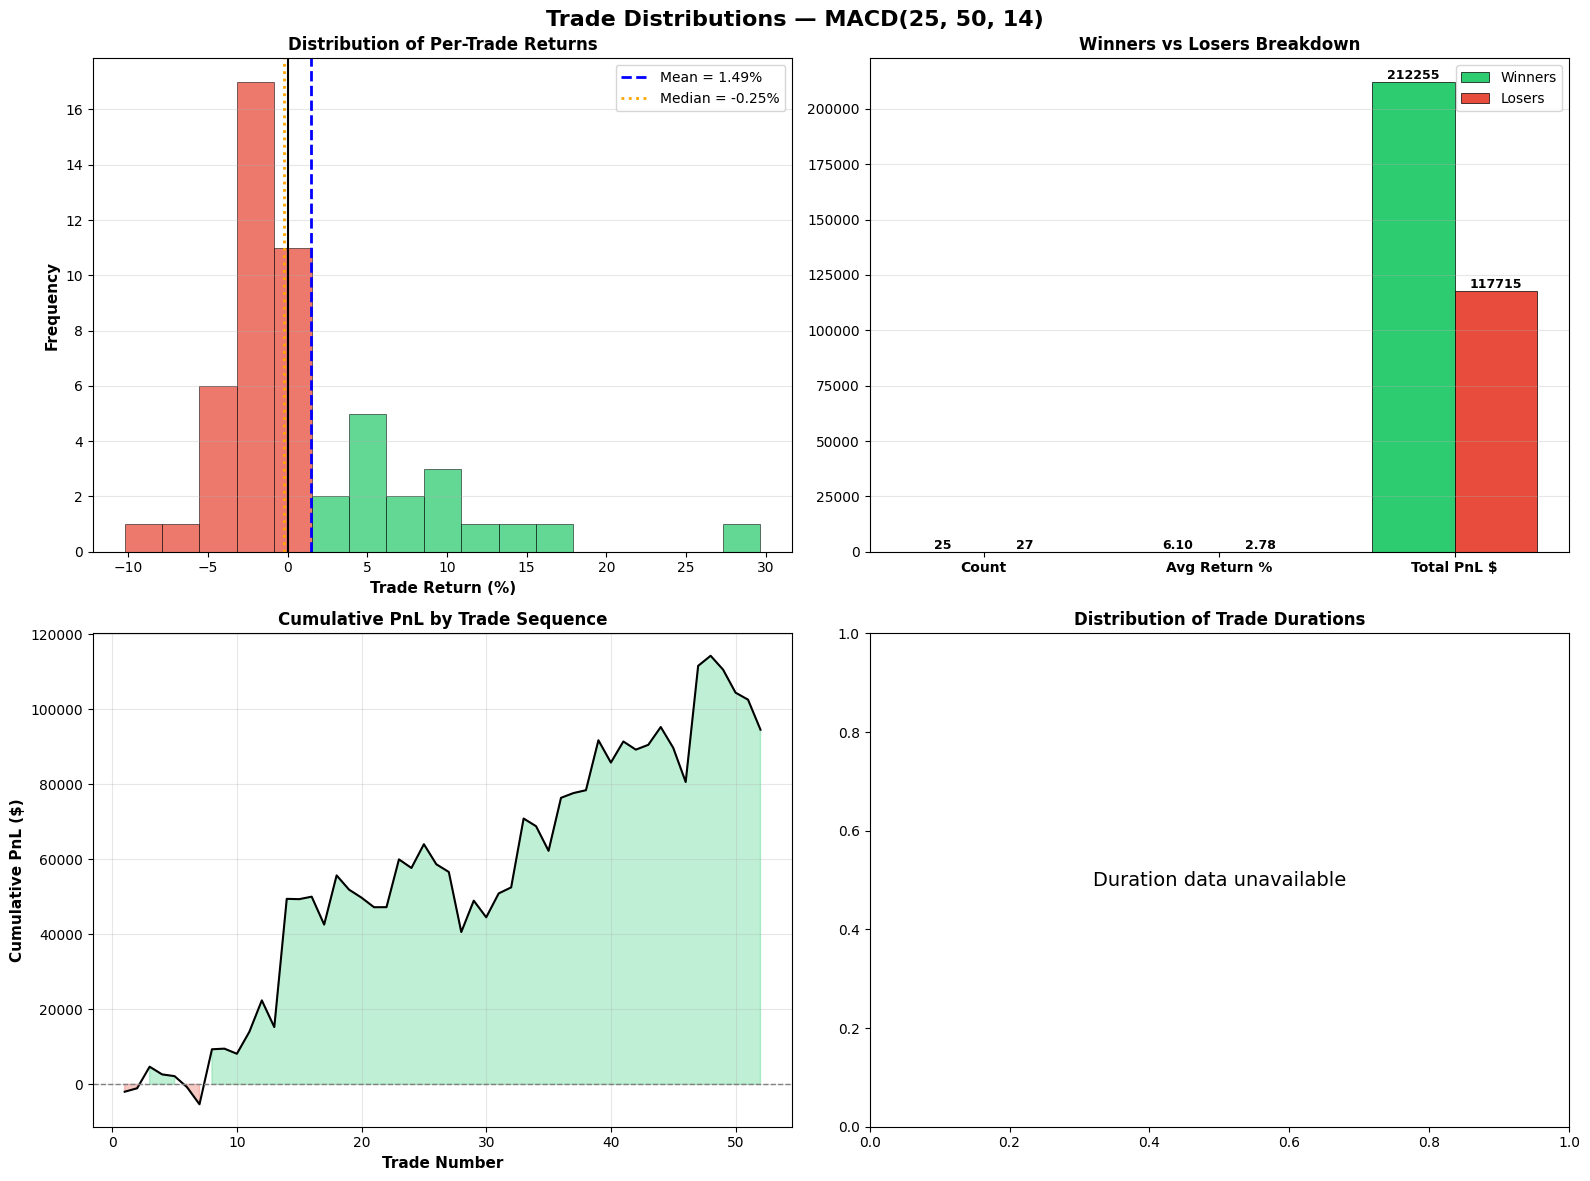

In [16]:
# TRADE RETURN DISTRIBUTIONS

trades_obj = pf_full.trades
trade_returns = trades_obj.returns.values
trade_pnl = trades_obj.pnl.values

wins = trade_returns[trade_returns > 0]
losses = trade_returns[trade_returns <= 0]

try:
    durations = trades_obj.duration
    if hasattr(durations, 'values'):
        dur_days = durations.dt.total_seconds().values / 86400 if hasattr(durations.iloc[0], 'total_seconds') else durations.values
    else:
        dur_days = np.array([float(d.total_seconds() / 86400) if hasattr(d, 'total_seconds') else float(d) for d in durations])
except:
    dur_days = None

print(f"Trade Statistics for MACD({fast_best}, {slow_best}, {signal_best}) — Full Period")
print("=" * 60)
print(f"Total Trades:    {len(trade_returns)}")
print(f"Winners:         {len(wins)} ({len(wins)/len(trade_returns)*100:.1f}%)")
print(f"Losers:          {len(losses)} ({len(losses)/len(trade_returns)*100:.1f}%)")
print(f"Mean Return:     {trade_returns.mean():.4f} ({trade_returns.mean()*100:.2f}%)")
print(f"Median Return:   {np.median(trade_returns):.4f}")
print(f"Std Dev:         {trade_returns.std():.4f}")
print(f"Skewness:        {float(pd.Series(trade_returns).skew()):.3f}")
print(f"Kurtosis:        {float(pd.Series(trade_returns).kurtosis()):.3f}")
print(f"Best Trade:      {trade_returns.max():.4f} ({trade_returns.max()*100:.2f}%)")
print(f"Worst Trade:     {trade_returns.min():.4f} ({trade_returns.min()*100:.2f}%)")
if len(wins) > 0 and len(losses) > 0:
    print(f"Avg Win:         {wins.mean():.4f} ({wins.mean()*100:.2f}%)")
    print(f"Avg Loss:        {losses.mean():.4f} ({losses.mean()*100:.2f}%)")
    print(f"Payoff Ratio:    {abs(wins.mean() / losses.mean()):.2f}x")
if dur_days is not None:
    print(f"Avg Duration:    {np.nanmean(dur_days):.1f} days")
    print(f"Median Duration: {np.nanmedian(dur_days):.1f} days")

# 4-PANEL TRADE DISTRIBUTION FIGURE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Trade Distributions — MACD({fast_best}, {slow_best}, {signal_best})',
             fontsize=16, fontweight='bold')

# Panel 1: Histogram of trade returns
ax = axes[0, 0]
n_bins = min(50, max(15, len(trade_returns) // 3))
n_ret, bins_ret, patches_ret = ax.hist(trade_returns * 100, bins=n_bins,
                                        edgecolor='black', linewidth=0.5, alpha=0.75)
for patch, left_edge in zip(patches_ret, bins_ret[:-1]):
    if left_edge >= 0:
        patch.set_facecolor('#2ecc71')
    else:
        patch.set_facecolor('#e74c3c')
ax.axvline(0, color='black', linewidth=1.5, linestyle='-')
ax.axvline(trade_returns.mean() * 100, color='blue', linewidth=2, linestyle='--',
           label=f'Mean = {trade_returns.mean()*100:.2f}%')
ax.axvline(np.median(trade_returns) * 100, color='orange', linewidth=2, linestyle=':',
           label=f'Median = {np.median(trade_returns)*100:.2f}%')
ax.set_xlabel('Trade Return (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Per-Trade Returns', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Win/Loss breakdown
ax = axes[0, 1]
if len(wins) > 0 and len(losses) > 0:
    categories = ['Count', 'Avg Return %', 'Total PnL $']
    win_vals = [len(wins), wins.mean() * 100, trade_pnl[trade_returns > 0].sum()]
    loss_vals = [len(losses), abs(losses.mean()) * 100, abs(trade_pnl[trade_returns <= 0].sum())]
    x = np.arange(len(categories))
    width = 0.35
    bars1 = ax.bar(x - width/2, win_vals, width, label='Winners', color='#2ecc71', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, loss_vals, width, label='Losers', color='#e74c3c', edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
    for bar in bars1:
        h = bar.get_height()
        fmt = f'{h:.0f}' if h > 10 else f'{h:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2., h, fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars2:
        h = bar.get_height()
        fmt = f'{h:.0f}' if h > 10 else f'{h:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2., h, fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Winners vs Losers Breakdown', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Panel 3: Cumulative PnL per trade
ax = axes[1, 0]
cum_pnl = np.cumsum(trade_pnl)
trade_nums = np.arange(1, len(trade_pnl) + 1)
ax.plot(trade_nums, cum_pnl, color='black', linewidth=1.5)
ax.fill_between(trade_nums, cum_pnl, where=(cum_pnl >= 0), color='#2ecc71', alpha=0.3)
ax.fill_between(trade_nums, cum_pnl, where=(cum_pnl < 0), color='#e74c3c', alpha=0.3)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_xlabel('Trade Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative PnL ($)', fontsize=11, fontweight='bold')
ax.set_title('Cumulative PnL by Trade Sequence', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 4: Trade duration distribution
ax = axes[1, 1]
if dur_days is not None and len(dur_days) > 0:
    valid_dur = dur_days[~np.isnan(dur_days)]
    if len(valid_dur) > 0:
        n_bins_d = min(40, max(10, len(valid_dur) // 3))
        ax.hist(valid_dur, bins=n_bins_d, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.75)
        ax.axvline(np.nanmean(valid_dur), color='blue', linewidth=2, linestyle='--',
                   label=f'Mean = {np.nanmean(valid_dur):.1f}d')
        ax.axvline(np.nanmedian(valid_dur), color='orange', linewidth=2, linestyle=':',
                   label=f'Median = {np.nanmedian(valid_dur):.1f}d')
        ax.set_xlabel('Trade Duration (days)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax.set_title('Distribution of Trade Durations', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Duration data unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=14)
else:
    ax.text(0.5, 0.5, 'Duration data unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=14)
    ax.set_title('Distribution of Trade Durations', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# STRATEGY PERFORMANCE RECEIPT — CLEAN STANDALONE FIGURE

full_total_return = float(pf_full.total_return())
full_ann_return = float(pf_full.annualized_return(freq='D'))
full_sharpe = float(pf_full.sharpe_ratio(freq='D'))
full_sortino = float(pf_full.sortino_ratio(freq='D'))
full_max_dd = float(pf_full.max_drawdown())
full_volatility = float(pf_full.annualized_volatility(freq='D'))
full_total_trades = len(pf_full.trades)

years_full = (close.index[-1] - close.index[0]).days / 365.25
full_cagr = (1 + full_total_return) ** (1 / max(years_full, 1e-9)) - 1

tr_full = pf_full.trades.returns.values
full_win_rate = (len(tr_full[tr_full > 0]) / len(tr_full) * 100) if len(tr_full) > 0 else 0
pos_g = tr_full[tr_full > 0].sum() if len(tr_full[tr_full > 0]) else 0
neg_l = abs(tr_full[tr_full < 0].sum()) if len(tr_full[tr_full < 0]) else 0
full_pf = pos_g / neg_l if neg_l > 0 else np.inf
full_trades_yr = full_total_trades / max(years_full, 1e-9)
full_expectancy = float(tr_full.mean()) if len(tr_full) > 0 else 0

daily_returns_receipt = pf_full.returns()
max_daily_loss = float(daily_returns_receipt.min())

# Consecutive loss streak
streak = 0
max_streak = 0
for r in tr_full:
    if r <= 0:
        streak += 1
        max_streak = max(max_streak, streak)
    else:
        streak = 0

# Calmar ratio
calmar = full_cagr / abs(full_max_dd) if abs(full_max_dd) > 1e-9 else np.inf

# FTMO checks
ftmo_daily_dd = abs(max_daily_loss) < 0.05
ftmo_overall_dd = abs(full_max_dd) < 0.10
ftmo_profit = full_cagr >= 0.10

# ============================================================
# RECEIPT FIGURE — Professional two-column layout
# ============================================================
fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 22)
ax.axis('off')

# Background
fig.patch.set_facecolor('#fefefe')

# Header
ax.text(5, 21.2, 'STRATEGY PERFORMANCE RECEIPT', fontsize=18, fontweight='bold',
        ha='center', va='center', fontfamily='monospace', color='#1a1a2e')
ax.plot([0.5, 9.5], [20.7, 20.7], color='#1a1a2e', linewidth=2)

# Strategy info
ax.text(5, 20.2, f'{TICKER}  |  MACD({fast_best},{slow_best},{signal_best})  |  {SIGNAL_MODE}',
        fontsize=13, ha='center', va='center', fontfamily='monospace', color='#333')
ax.text(5, 19.6, f'{close.index[0].date()}  to  {close.index[-1].date()}  ({years_full:.1f} years)',
        fontsize=11, ha='center', va='center', fontfamily='monospace', color='#666')
ax.plot([0.5, 9.5], [19.1, 19.1], color='#ccc', linewidth=1, linestyle='--')

def receipt_row(y, label, value, color='#1a1a2e', bold=False):
    weight = 'bold' if bold else 'normal'
    ax.text(1.0, y, label, fontsize=11, ha='left', va='center', fontfamily='monospace',
            color='#555', fontweight=weight)
    ax.text(9.0, y, value, fontsize=11, ha='right', va='center', fontfamily='monospace',
            color=color, fontweight='bold')

# RETURNS section
y = 18.5
ax.text(5, y, 'RETURNS', fontsize=12, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color='#0d47a1')
y -= 0.55
receipt_row(y, 'Total Return', f'{full_total_return:+.2%}',
            color='#2e7d32' if full_total_return > 0 else '#c62828')
y -= 0.45
receipt_row(y, 'CAGR', f'{full_cagr:+.2%}',
            color='#2e7d32' if full_cagr > 0 else '#c62828')
y -= 0.45
receipt_row(y, 'Annualized Return', f'{full_ann_return:+.2%}',
            color='#2e7d32' if full_ann_return > 0 else '#c62828')

y -= 0.7
ax.plot([0.5, 9.5], [y + 0.15, y + 0.15], color='#ccc', linewidth=1, linestyle='--')

# RISK-ADJUSTED section
ax.text(5, y, 'RISK-ADJUSTED', fontsize=12, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color='#0d47a1')
y -= 0.55
receipt_row(y, 'Sharpe Ratio', f'{full_sharpe:.3f}',
            color='#2e7d32' if full_sharpe > 0.5 else '#f57f17' if full_sharpe > 0 else '#c62828')
y -= 0.45
receipt_row(y, 'Sortino Ratio', f'{full_sortino:.3f}',
            color='#2e7d32' if full_sortino > 0.5 else '#c62828')
y -= 0.45
receipt_row(y, 'Calmar Ratio', f'{calmar:.3f}' if calmar < 100 else 'INF')
y -= 0.45
receipt_row(y, 'Volatility', f'{full_volatility:.2%}')

y -= 0.7
ax.plot([0.5, 9.5], [y + 0.15, y + 0.15], color='#ccc', linewidth=1, linestyle='--')

# RISK section
ax.text(5, y, 'RISK', fontsize=12, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color='#0d47a1')
y -= 0.55
receipt_row(y, 'Max Drawdown', f'{full_max_dd:.2%}',
            color='#c62828' if abs(full_max_dd) > 0.10 else '#f57f17' if abs(full_max_dd) > 0.05 else '#2e7d32')
y -= 0.45
receipt_row(y, 'Max Daily Loss', f'{max_daily_loss:.2%}',
            color='#c62828' if abs(max_daily_loss) > 0.05 else '#2e7d32')
y -= 0.45
receipt_row(y, 'Max Loss Streak', f'{max_streak} trades')

y -= 0.7
ax.plot([0.5, 9.5], [y + 0.15, y + 0.15], color='#ccc', linewidth=1, linestyle='--')

# TRADE STATS section
ax.text(5, y, 'TRADE STATISTICS', fontsize=12, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color='#0d47a1')
y -= 0.55
receipt_row(y, 'Total Trades', f'{full_total_trades}')
y -= 0.45
receipt_row(y, 'Trades / Year', f'{full_trades_yr:.1f}',
            color='#2e7d32' if full_trades_yr > 30 else '#f57f17' if full_trades_yr > 10 else '#c62828')
y -= 0.45
receipt_row(y, 'Win Rate', f'{full_win_rate:.1f}%',
            color='#2e7d32' if full_win_rate > 50 else '#c62828')
y -= 0.45
receipt_row(y, 'Profit Factor', f'{full_pf:.2f}' if full_pf < 100 else 'INF',
            color='#2e7d32' if full_pf > 1.5 else '#f57f17' if full_pf > 1.0 else '#c62828')
y -= 0.45
receipt_row(y, 'Expectancy', f'{full_expectancy:.4f}',
            color='#2e7d32' if full_expectancy > 0 else '#c62828')

y -= 0.7
ax.plot([0.5, 9.5], [y + 0.15, y + 0.15], color='#1a1a2e', linewidth=2)

# FTMO CHALLENGE section
ax.text(5, y, 'FTMO CHALLENGE READINESS', fontsize=12, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color='#0d47a1')
y -= 0.55
receipt_row(y, 'Daily DD < 5%', 'PASS' if ftmo_daily_dd else 'FAIL',
            color='#2e7d32' if ftmo_daily_dd else '#c62828')
y -= 0.45
receipt_row(y, 'Overall DD < 10%', 'PASS' if ftmo_overall_dd else 'FAIL',
            color='#2e7d32' if ftmo_overall_dd else '#c62828')
y -= 0.45
receipt_row(y, 'CAGR > 10%', 'PASS' if ftmo_profit else 'FAIL',
            color='#2e7d32' if ftmo_profit else '#c62828')

y -= 0.6
overall_pass = ftmo_daily_dd and ftmo_overall_dd
verdict_color = '#2e7d32' if overall_pass else '#c62828'
verdict_text = 'FTMO VIABLE' if overall_pass else 'REVIEW RISK LIMITS'
ax.text(5, y, verdict_text, fontsize=16, fontweight='bold', ha='center', va='center',
        fontfamily='monospace', color=verdict_color,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=verdict_color, alpha=0.1, edgecolor=verdict_color))

# Bottom border
ax.plot([0.5, 9.5], [y - 0.6, y - 0.6], color='#1a1a2e', linewidth=2)

plt.tight_layout()
plt.show()

# Print summary
print("FTMO CHALLENGE READINESS")
print("=" * 50)
print(f"Max Daily Loss:      {max_daily_loss:.2%}  (Limit: -5.00%)  {'PASS' if ftmo_daily_dd else 'FAIL'}")
print(f"Max Overall DD:      {full_max_dd:.2%}  (Limit: -10.00%) {'PASS' if ftmo_overall_dd else 'FAIL'}")
print(f"CAGR:                {full_cagr:.2%}  (Target: +10.00%) {'PASS' if ftmo_profit else 'FAIL'}")
print(f"Trades/Year:         {full_trades_yr:.1f}")
print(f"\nOverall Assessment:  {'FTMO VIABLE' if overall_pass else 'REVIEW RISK LIMITS'}")

---
## Section 11: Monte Carlo Simulation

Bootstrap the realized trade returns to simulate 1,000 alternative equity paths. This answers:
- **How lucky/unlucky were we?** (terminal wealth distribution)
- **What's the worst realistic drawdown?** (max DD distribution)
- **Is the strategy robust or just one favorable sequence?** (confidence intervals)

Method: resample with replacement from the actual per-trade return series, reconstruct equity paths, compute statistics across all simulations.

In [ ]:
# MONTE CARLO SIMULATION — BOOTSTRAPPED TRADE RETURNS
#
# Resample the actual per-trade returns with replacement to generate
# 1,000 alternative equity paths. This tells you whether the backtest
# result is robust or just one lucky ordering of trades.

N_SIMULATIONS = 1000
INITIAL_CAPITAL = 100_000

# Use the actual trade returns from the full-period backtest
mc_trade_returns = pf_full.trades.returns.values
n_trades = len(mc_trade_returns)

print(f"Monte Carlo Simulation")
print(f"=" * 60)
print(f"Source: {n_trades} actual trades from MACD({fast_best},{slow_best},{signal_best})")
print(f"Simulations: {N_SIMULATIONS}")
print(f"Initial Capital: ${INITIAL_CAPITAL:,.0f}")
print(f"Method: Bootstrap resampling with replacement")

if n_trades < 5:
    print("\nWARNING: Too few trades for meaningful Monte Carlo. Need at least 5.")
else:
    # Run simulations
    np.random.seed(42)
    terminal_values = np.zeros(N_SIMULATIONS)
    max_drawdowns_mc = np.zeros(N_SIMULATIONS)
    all_equity_paths = np.zeros((N_SIMULATIONS, n_trades + 1))

    for sim in range(N_SIMULATIONS):
        # Resample trade returns with replacement
        shuffled_returns = np.random.choice(mc_trade_returns, size=n_trades, replace=True)

        # Build equity curve from trade returns
        # Each trade return is applied to current equity
        equity = np.zeros(n_trades + 1)
        equity[0] = INITIAL_CAPITAL
        for t in range(n_trades):
            equity[t + 1] = equity[t] * (1 + shuffled_returns[t])

        all_equity_paths[sim] = equity
        terminal_values[sim] = equity[-1]

        # Max drawdown for this path
        running_max = np.maximum.accumulate(equity)
        drawdowns = (equity - running_max) / running_max
        max_drawdowns_mc[sim] = drawdowns.min()

    # Compute percentiles for fan chart
    percentiles = [5, 10, 25, 50, 75, 90, 95]
    pct_curves = np.percentile(all_equity_paths, percentiles, axis=0)

    # Actual equity path (original trade order)
    actual_equity = np.zeros(n_trades + 1)
    actual_equity[0] = INITIAL_CAPITAL
    for t in range(n_trades):
        actual_equity[t + 1] = actual_equity[t] * (1 + mc_trade_returns[t])

    actual_terminal = actual_equity[-1]
    actual_return = (actual_terminal / INITIAL_CAPITAL - 1) * 100

    # Where does the actual result fall in the distribution?
    actual_percentile = stats.percentileofscore(terminal_values, actual_terminal)

    print(f"\nSimulation Complete!")
    print(f"\n{'Metric':<30} {'Value':>15}")
    print("-" * 47)
    print(f"{'Actual Terminal Value':<30} ${actual_terminal:>14,.0f}")
    print(f"{'Actual Total Return':<30} {actual_return:>14.1f}%")
    print(f"{'Actual Percentile Rank':<30} {actual_percentile:>14.1f}%")
    print(f"{'Median Terminal Value':<30} ${np.median(terminal_values):>14,.0f}")
    print(f"{'Mean Terminal Value':<30} ${np.mean(terminal_values):>14,.0f}")
    print(f"{'5th Percentile (worst case)':<30} ${np.percentile(terminal_values, 5):>14,.0f}")
    print(f"{'95th Percentile (best case)':<30} ${np.percentile(terminal_values, 95):>14,.0f}")
    print(f"{'P(Profitable)':<30} {(terminal_values > INITIAL_CAPITAL).mean()*100:>14.1f}%")
    print(f"{'P(Lose > 20%)':<30} {(terminal_values < INITIAL_CAPITAL * 0.80).mean()*100:>14.1f}%")
    print(f"{'Median Max Drawdown':<30} {np.median(max_drawdowns_mc)*100:>14.1f}%")
    print(f"{'95th Pctile Max Drawdown':<30} {np.percentile(max_drawdowns_mc, 5)*100:>14.1f}%")

    # ============================================================
    # FIGURE 1: EQUITY FAN CHART
    # ============================================================
    trade_nums = np.arange(n_trades + 1)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(f'Monte Carlo Analysis — MACD({fast_best},{slow_best},{signal_best}) ({SIGNAL_MODE}) | {N_SIMULATIONS} Simulations',
                 fontsize=16, fontweight='bold')

    # Panel 1: Equity fan chart
    ax = axes[0, 0]
    # Plot a random sample of paths in light gray
    sample_idx = np.random.choice(N_SIMULATIONS, size=min(100, N_SIMULATIONS), replace=False)
    for idx in sample_idx:
        ax.plot(trade_nums, all_equity_paths[idx], color='#bdbdbd', alpha=0.15, linewidth=0.5)

    # Percentile bands
    ax.fill_between(trade_nums, pct_curves[0], pct_curves[6], alpha=0.12, color='#1565c0', label='5th-95th pctile')
    ax.fill_between(trade_nums, pct_curves[1], pct_curves[5], alpha=0.18, color='#1565c0', label='10th-90th pctile')
    ax.fill_between(trade_nums, pct_curves[2], pct_curves[4], alpha=0.25, color='#1565c0', label='25th-75th pctile')

    # Median and actual
    ax.plot(trade_nums, pct_curves[3], color='#0d47a1', linewidth=2, linestyle='--', label='Median Path')
    ax.plot(trade_nums, actual_equity, color='#d32f2f', linewidth=2.5, label=f'Actual ({actual_percentile:.0f}th pctile)')

    ax.axhline(INITIAL_CAPITAL, color='black', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Trade Number', fontsize=11, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($)', fontsize=11, fontweight='bold')
    ax.set_title('Equity Fan Chart (Bootstrapped Paths)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.2)

    # Panel 2: Terminal wealth distribution
    ax = axes[0, 1]
    n_bins = min(60, max(20, N_SIMULATIONS // 15))
    n_hist, bins_hist, patches_hist = ax.hist(terminal_values / 1000, bins=n_bins,
                                               edgecolor='white', linewidth=0.5, alpha=0.8, color='#1565c0')
    # Color bars: green if profitable, red if loss
    for patch, left_edge in zip(patches_hist, bins_hist[:-1]):
        if left_edge >= INITIAL_CAPITAL / 1000:
            patch.set_facecolor('#2e7d32')
        else:
            patch.set_facecolor('#c62828')

    ax.axvline(actual_terminal / 1000, color='#d32f2f', linewidth=2.5, linestyle='-',
               label=f'Actual: ${actual_terminal/1000:.0f}K')
    ax.axvline(np.median(terminal_values) / 1000, color='#0d47a1', linewidth=2, linestyle='--',
               label=f'Median: ${np.median(terminal_values)/1000:.0f}K')
    ax.axvline(INITIAL_CAPITAL / 1000, color='black', linewidth=1.5, linestyle=':',
               label=f'Breakeven: ${INITIAL_CAPITAL/1000:.0f}K')
    ax.set_xlabel('Terminal Portfolio Value ($K)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Terminal Wealth Distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

    # Panel 3: Max drawdown distribution
    ax = axes[1, 0]
    dd_pct = max_drawdowns_mc * 100  # negative values
    n_hist_dd, bins_dd, patches_dd = ax.hist(dd_pct, bins=n_bins,
                                              edgecolor='white', linewidth=0.5, alpha=0.8, color='#c62828')
    # Mark FTMO limits
    ax.axvline(-5, color='orange', linewidth=2, linestyle='--', label='FTMO Daily Limit (-5%)')
    ax.axvline(-10, color='red', linewidth=2, linestyle='-', label='FTMO Max DD (-10%)')

    actual_max_dd_mc = (np.min((actual_equity - np.maximum.accumulate(actual_equity)) /
                                np.maximum.accumulate(actual_equity))) * 100
    ax.axvline(actual_max_dd_mc, color='#0d47a1', linewidth=2.5, linestyle='-',
               label=f'Actual: {actual_max_dd_mc:.1f}%')

    pct_breach_10 = (max_drawdowns_mc < -0.10).mean() * 100
    pct_breach_5 = (max_drawdowns_mc < -0.05).mean() * 100
    ax.set_xlabel('Maximum Drawdown (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Max Drawdown Distribution (P(breach 10%)={pct_breach_10:.0f}%)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', alpha=0.2)

    # Panel 4: Return vs Risk scatter (each sim is a dot)
    ax = axes[1, 1]
    sim_returns = (terminal_values / INITIAL_CAPITAL - 1) * 100
    sim_max_dd_pct = max_drawdowns_mc * 100

    scatter = ax.scatter(sim_max_dd_pct, sim_returns, c=sim_returns, cmap='RdYlGn',
                        s=8, alpha=0.5, edgecolor='none')
    ax.scatter(actual_max_dd_mc, actual_return, c='red', s=150, marker='*',
               edgecolor='black', linewidth=1.5, zorder=10, label=f'Actual Result')
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.axvline(-10, color='red', linewidth=1, linestyle='--', alpha=0.5, label='FTMO -10% DD')

    ax.set_xlabel('Max Drawdown (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Return (%)', fontsize=11, fontweight='bold')
    ax.set_title('Return vs Risk (Each Dot = 1 Simulation)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.colorbar(scatter, ax=ax, label='Return %', shrink=0.8)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # SUMMARY TABLE
    # ============================================================
    print("\nMonte Carlo Confidence Intervals")
    print("=" * 60)
    for p in [5, 10, 25, 50, 75, 90, 95]:
        tv = np.percentile(terminal_values, p)
        ret = (tv / INITIAL_CAPITAL - 1) * 100
        dd = np.percentile(max_drawdowns_mc, 100 - p) * 100
        print(f"  {p:3d}th pctile:  Terminal=${tv:>10,.0f}  Return={ret:>+7.1f}%  MaxDD={dd:>6.1f}%")

    print(f"\nFTMO Risk Assessment:")
    print(f"  P(Max DD > 5%):  {pct_breach_5:.1f}% of simulations")
    print(f"  P(Max DD > 10%): {pct_breach_10:.1f}% of simulations")
    print(f"  P(Profitable):   {(terminal_values > INITIAL_CAPITAL).mean()*100:.1f}%")